# Proyecto Final: Estadistica y Analisis Exploratorio de Datos

**Dataset:** Heart Disease - Cleveland Clinic Foundation (UCI Machine Learning Repository, 303 registros).

Notebook reproducible que resuelve los puntos 2 a 29 del taller. Genera figuras PNG, tablas CSV y un Excel
consolidado en las carpetas `./figuras_taller` y `./entregables_taller`. Todas las interpretaciones
clinicas y conclusiones se redactan junto a cada bloque de codigo.

> Esta version incorpora las correcciones de revision:
> - rutas locales relativas en lugar de `/content/...`,
> - typo en la celda Gaussiana bivariada (`bviv_mu`),
> - Welch + d de Cohen coherentes con Levene + IC de la diferencia,
> - ANOVA con verificacion de supuestos y Kruskal-Wallis de respaldo,
> - codificacion alineada estrictamente a la rubrica (`sex`/`exang` -> Label, `cp`/`restecg` -> One-Hot, `slope` -> Ordinal),
> - tabla resumen de inferencia con columna de conclusion explicita,
> - estetica unificada (paleta, anotaciones, dpi=160).

In [1]:
# pip already installed in local env

## 1. Librerias, configuracion y carga de datos

In [2]:
import warnings, os, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (chi2, t, norm, shapiro, kstest, levene, f_oneway,
                         kruskal, multivariate_normal, beta as beta_dist,
                         gamma as gamma_dist, expon)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,
                                   MinMaxScaler, StandardScaler)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportion_confint

# Constantes
RANDOM_STATE = 42
TEST_SIZE = 0.20
ALPHA = 0.05
FIG_DPI = 160

# Paleta y estilo unificados
sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
PRIMARY = '#4C72B0'
SECONDARY = '#55A868'
ACCENT = '#C44E52'
NEUTRAL = '#4D4D4D'
DISEASE_PALETTE = ['#55A868', '#C44E52']   # 0=sano, 1=enfermo

plt.rcParams.update({
    'figure.figsize': (9, 5), 'figure.dpi': 100, 'savefig.dpi': FIG_DPI,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'legend.fontsize': 10, 'axes.spines.top': False, 'axes.spines.right': False,
})

# Rutas locales (reemplazan a /content/... del entorno Colab original)
FIG_DIR = './figuras_taller'
OUT_DIR = './entregables_taller'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Carga del dataset UCI
COLUMNAS = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
            'exang','oldpeak','slope','ca','thal','num']
UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
RAW_FALLBACK = 'https://raw.githubusercontent.com/StatQuest/logistic_regression_demo/master/processed.cleveland.data'
try:
    df = pd.read_csv(UCI_URL, names=COLUMNAS, na_values='?')
except Exception:
    df = pd.read_csv(RAW_FALLBACK, names=COLUMNAS, na_values='?')

# num: 0 = sano, 1-4 = presencia de enfermedad. Variable objetivo binaria.
df['disease'] = (df['num'] > 0).astype(int)
for col in ['sex','cp','fbs','restecg','exang','slope','ca','thal','num','disease']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


## 2. Diccionario de variables y clasificacion estadistica

In [3]:
diccionario = pd.DataFrame([
    ['age','Cuantitativa continua','29-77','Edad del paciente en anios'],
    ['sex','Categorica nominal binaria','0=mujer, 1=hombre','Sexo biologico reportado'],
    ['cp','Categorica nominal','1=angina tipica, 2=angina atipica, 3=dolor no anginoso, 4=asintomatico','Tipo de dolor pectoral'],
    ['trestbps','Cuantitativa continua','94-200','Presion arterial en reposo, mm Hg'],
    ['chol','Cuantitativa continua','126-564','Colesterol serico, mg/dl'],
    ['fbs','Categorica nominal binaria','0=falso, 1=verdadero','Azucar en ayunas > 120 mg/dl'],
    ['restecg','Categorica nominal','0=normal, 1=ST-T anormal, 2=hipertrofia ventricular probable','Electrocardiograma en reposo'],
    ['thalach','Cuantitativa continua','71-202','Frecuencia cardiaca maxima alcanzada'],
    ['exang','Categorica nominal binaria','0=no, 1=si','Angina inducida por ejercicio'],
    ['oldpeak','Cuantitativa continua','0-6.2','Depresion ST inducida por ejercicio'],
    ['slope','Categorica ordinal','1=ascendente, 2=plana, 3=descendente','Pendiente del segmento ST'],
    ['ca','Cuantitativa discreta / ordinal','0-3','Vasos principales coloreados por fluoroscopia'],
    ['thal','Categorica nominal','3=normal, 6=defecto fijo, 7=defecto reversible','Resultado thalassemia'],
    ['num','Categorica ordinal','0-4','Diagnostico original'],
    ['disease','Categorica nominal binaria','0=sano, 1=enfermo','Objetivo binario derivado de num']
], columns=['Variable','Tipo','Valores','Descripcion'])

clasificacion = pd.DataFrame([
    ['age',str(df['age'].dtype),'continua','razon'],
    ['sex',str(df['sex'].dtype),'nominal binaria','nominal'],
    ['cp',str(df['cp'].dtype),'nominal','nominal'],
    ['trestbps',str(df['trestbps'].dtype),'continua','razon'],
    ['chol',str(df['chol'].dtype),'continua','razon'],
    ['fbs',str(df['fbs'].dtype),'nominal binaria','nominal'],
    ['restecg',str(df['restecg'].dtype),'nominal','nominal'],
    ['thalach',str(df['thalach'].dtype),'continua','razon'],
    ['exang',str(df['exang'].dtype),'nominal binaria','nominal'],
    ['oldpeak',str(df['oldpeak'].dtype),'continua','razon'],
    ['slope',str(df['slope'].dtype),'ordinal','ordinal'],
    ['ca',str(df['ca'].dtype),'discreta','razon'],
    ['thal',str(df['thal'].dtype),'nominal','nominal'],
    ['num',str(df['num'].dtype),'ordinal','ordinal'],
    ['disease',str(df['disease'].dtype),'nominal binaria','nominal']
], columns=['Variable','Tipo Python','Tipo estadistico','Escala de medicion'])

diccionario.to_csv(f'{OUT_DIR}/tabla_variables.csv', index=False)
clasificacion.to_csv(f'{OUT_DIR}/clasificacion_variables.csv', index=False)
display(diccionario); display(clasificacion)

,Variable,Tipo,Valores,Descripcion
0,age,Cuantitativa continua,29-77,Edad del paciente en anios
1,sex,Categorica nominal binaria,"0=mujer, 1=hombre",Sexo biologico reportado
2,cp,Categorica nominal,"1=angina tipica, 2=angina atipica, 3=dolor no ...",Tipo de dolor pectoral
3,trestbps,Cuantitativa continua,94-200,"Presion arterial en reposo, mm Hg"
4,chol,Cuantitativa continua,126-564,"Colesterol serico, mg/dl"
5,fbs,Categorica nominal binaria,"0=falso, 1=verdadero",Azucar en ayunas > 120 mg/dl
6,restecg,Categorica nominal,"0=normal, 1=ST-T anormal, 2=hipertrofia ventri...",Electrocardiograma en reposo
7,thalach,Cuantitativa continua,71-202,Frecuencia cardiaca maxima alcanzada
8,exang,Categorica nominal binaria,"0=no, 1=si",Angina inducida por ejercicio
9,oldpeak,Cuantitativa continua,0-6.2,Depresion ST inducida por ejercicio


,Variable,Tipo Python,Tipo estadistico,Escala de medicion
0,age,float64,continua,razon
1,sex,float64,nominal binaria,nominal
2,cp,float64,nominal,nominal
3,trestbps,float64,continua,razon
4,chol,float64,continua,razon
5,fbs,float64,nominal binaria,nominal
6,restecg,float64,nominal,nominal
7,thalach,float64,continua,razon
8,exang,float64,nominal binaria,nominal
9,oldpeak,float64,continua,razon


## 3. Diagnostico inicial

In [4]:
print('Shape:', df.shape)
print('Duplicados:', df.duplicated().sum())
print('\nTipos:'); print(df.dtypes)
print('\nFaltantes por columna:'); print(df.isna().sum())

diagnostico = pd.DataFrame({
    'tipo_python': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    'faltantes_%': (df.isna().mean()*100).round(2),
    'unicos': df.nunique(dropna=True)
})
display(df.describe(include='all').T)
display(diagnostico)
diagnostico.to_csv(f'{OUT_DIR}/diagnostico_inicial.csv')

Shape: (303, 15)
Duplicados: 0

Tipos:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
disease       int32
dtype: object

Faltantes por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
disease     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


,tipo_python,faltantes,faltantes_%,unicos
age,float64,0,0.00,41
sex,float64,0,0.00,2
cp,float64,0,0.00,4
trestbps,float64,0,0.00,50
chol,float64,0,0.00,152
fbs,float64,0,0.00,2
restecg,float64,0,0.00,3
thalach,float64,0,0.00,91
exang,float64,0,0.00,2
oldpeak,float64,0,0.00,40


**Interpretacion clinica.** El dataset tiene 303 pacientes, sin duplicados.
Solo `ca` (4 faltantes, 1.32%) y `thal` (2 faltantes, 0.66%) presentan datos
ausentes - codificados originalmente como `?` por UCI. La proporcion es lo
suficientemente baja para imputar sin riesgo de sesgo. Todas las variables
categoricas se cargan como float (incluyendo `sex`, `cp`, `fbs`, etc.) porque
los NaN obligan a tipo flotante; se mantienen asi y se trataran como
categoricas o ordinales segun corresponda en el pipeline.

## 4. Estadisticos descriptivos e interpretacion

In [5]:
NUMERIC_VARS = ['age','trestbps','chol','thalach','oldpeak','ca']
CONTINUOUS_VARS = ['age','trestbps','chol','thalach','oldpeak']
CATEGORICAL_VARS = ['sex','cp','fbs','restecg','exang','slope','thal','disease']

desc = pd.DataFrame(index=NUMERIC_VARS)
desc['media'] = df[NUMERIC_VARS].mean()
desc['mediana'] = df[NUMERIC_VARS].median()
desc['moda'] = df[NUMERIC_VARS].mode(dropna=True).iloc[0]
desc['varianza'] = df[NUMERIC_VARS].var(ddof=1)
desc['desv_std'] = df[NUMERIC_VARS].std(ddof=1)
desc['coef_variacion_%'] = desc['desv_std']/desc['media']*100
desc['asimetria'] = df[NUMERIC_VARS].skew()
desc['curtosis'] = df[NUMERIC_VARS].kurtosis()
display(desc.round(3))

for var, row in desc.iterrows():
    sesgo = ('aproximadamente simetrica' if abs(row['asimetria']) < 0.5
             else ('sesgada a la derecha' if row['asimetria'] > 0
                   else 'sesgada a la izquierda'))
    pico = ('mesocurtica/aproximada a normal' if abs(row['curtosis']) < 0.5
            else ('leptocurtica, colas pesadas' if row['curtosis'] > 0
                  else 'platicurtica, mas plana'))
    print(f'{var}: media={row["media"]:.2f}, mediana={row["mediana"]:.2f}; '
          f'{sesgo}; {pico}; CV={row["coef_variacion_%"]:.1f}%.')

desc.round(4).to_csv(f'{OUT_DIR}/estadisticos_descriptivos.csv')

,media,mediana,moda,varianza,desv_std,coef_variacion_%,asimetria,curtosis
age,54.439,56.0,58.0,81.697,9.039,16.603,-0.209,-0.523
trestbps,131.690,130.0,120.0,309.751,17.600,13.365,0.706,0.880
chol,246.693,241.0,197.0,2680.849,51.777,20.988,1.136,4.492
thalach,149.607,153.0,162.0,523.266,22.875,15.290,-0.537,-0.054
oldpeak,1.040,0.8,0.0,1.348,1.161,111.684,1.270,1.576
ca,0.672,0.0,0.0,0.879,0.937,139.450,1.189,0.259


age: media=54.44, mediana=56.00; aproximadamente simetrica; platicurtica, mas plana; CV=16.6%.
trestbps: media=131.69, mediana=130.00; sesgada a la derecha; leptocurtica, colas pesadas; CV=13.4%.
chol: media=246.69, mediana=241.00; sesgada a la derecha; leptocurtica, colas pesadas; CV=21.0%.
thalach: media=149.61, mediana=153.00; sesgada a la izquierda; mesocurtica/aproximada a normal; CV=15.3%.
oldpeak: media=1.04, mediana=0.80; sesgada a la derecha; leptocurtica, colas pesadas; CV=111.7%.
ca: media=0.67, mediana=0.00; sesgada a la derecha; mesocurtica/aproximada a normal; CV=139.4%.


**Interpretacion clinica.** La edad esta casi simetricamente distribuida con media 54 y mediana 56 anios,
poblacion adulta-mayor consistente con el riesgo cardiovascular. El colesterol muestra sesgo a la derecha
y curtosis alta (4.5), tipico de marcadores bioquimicos con valores extremos clinicamente plausibles. La
frecuencia cardiaca maxima `thalach` esta levemente sesgada a la izquierda (los enfermos alcanzan FC mas
bajas, comprimiendo la cola inferior). `oldpeak` y `ca` tienen CV > 100% porque la mayoria de pacientes
sanos registran cero, generando exceso de masa en el origen.

## 5. Distribuciones univariadas y categoricas

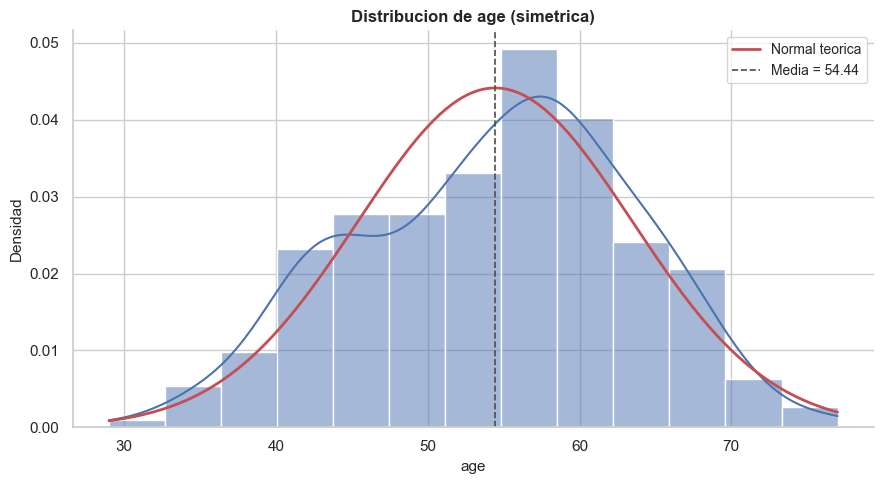

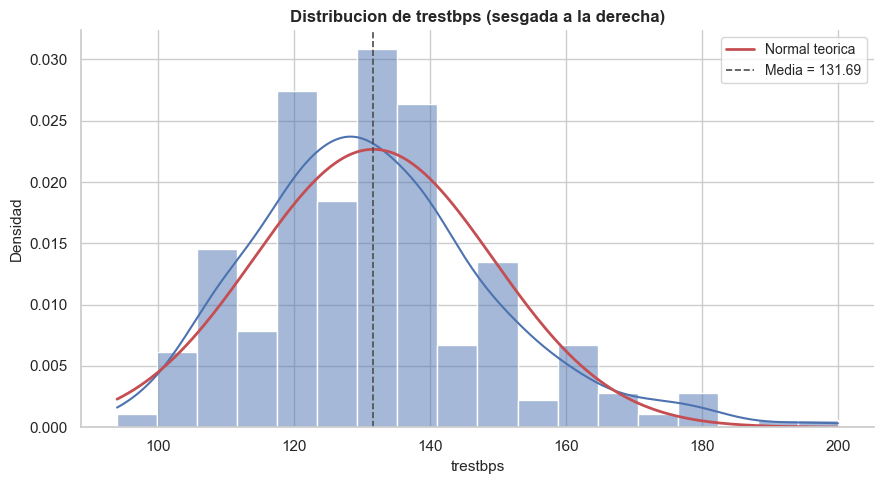

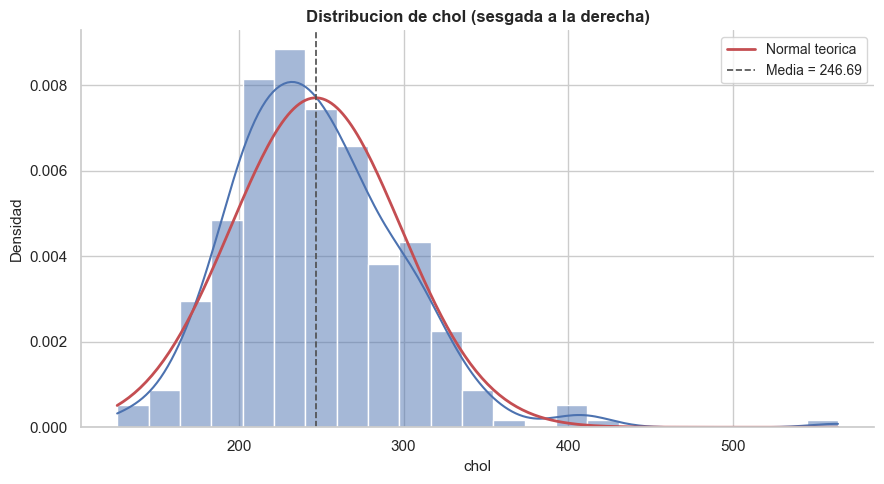

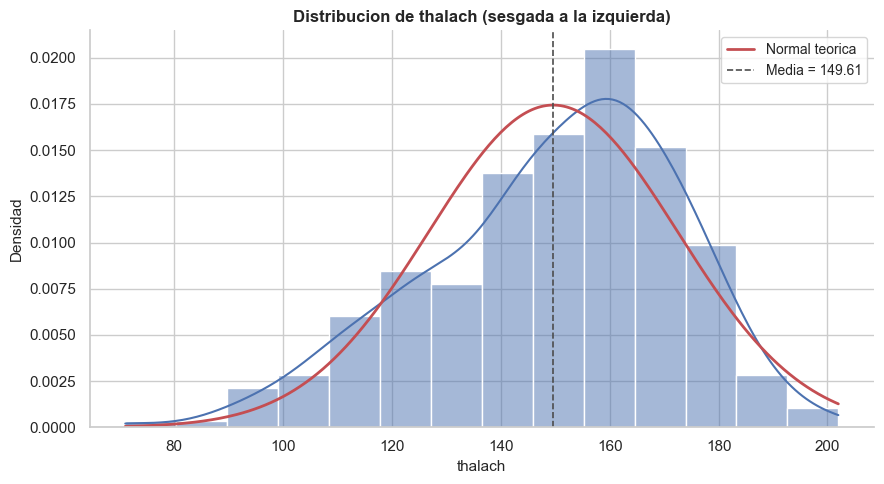

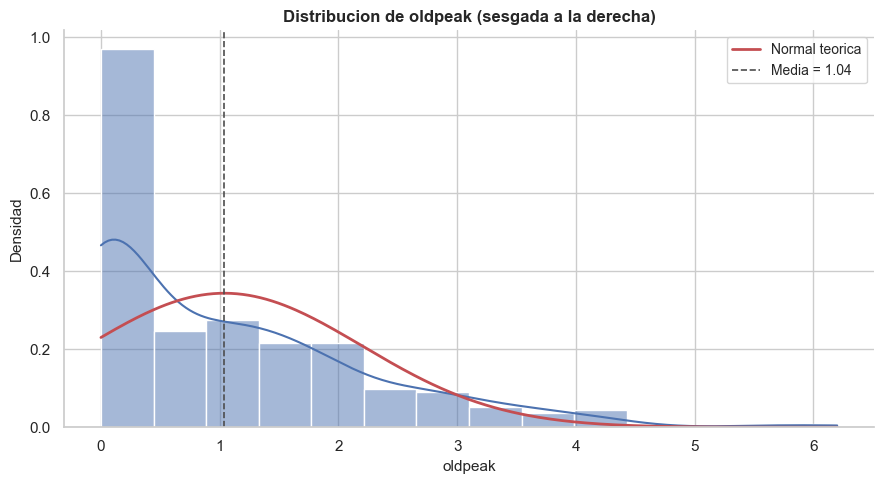

,variable,asimetria,forma
0,age,-0.209,simetrica
1,trestbps,0.706,sesgada a la derecha
2,chol,1.136,sesgada a la derecha
3,thalach,-0.537,sesgada a la izquierda
4,oldpeak,1.270,sesgada a la derecha



sex


,frecuencia,porcentaje
sex,,
0.0,97,32.01
1.0,206,67.99


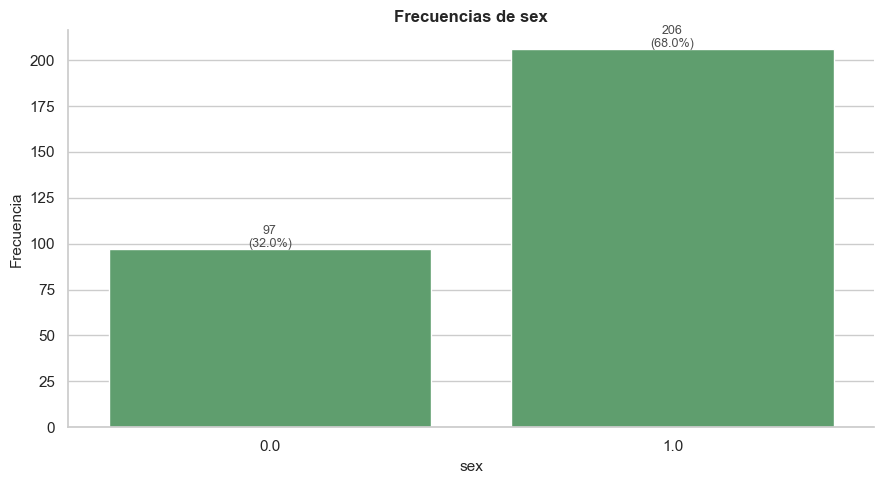


cp


,frecuencia,porcentaje
cp,,
1.0,23,7.59
2.0,50,16.50
3.0,86,28.38
4.0,144,47.52


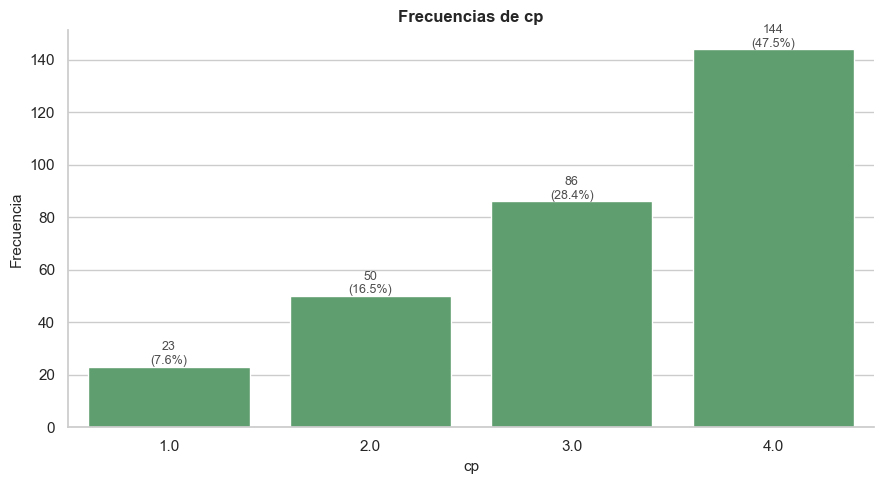


fbs


,frecuencia,porcentaje
fbs,,
0.0,258,85.15
1.0,45,14.85


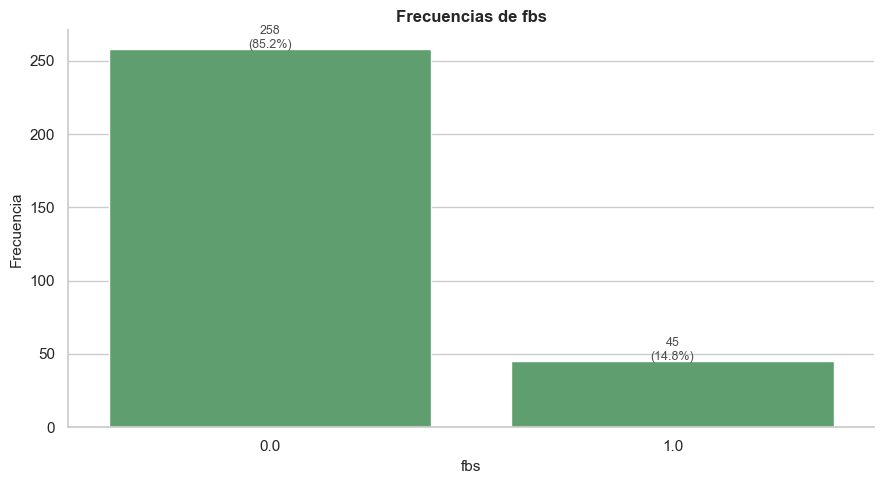


restecg


,frecuencia,porcentaje
restecg,,
0.0,151,49.83
1.0,4,1.32
2.0,148,48.84


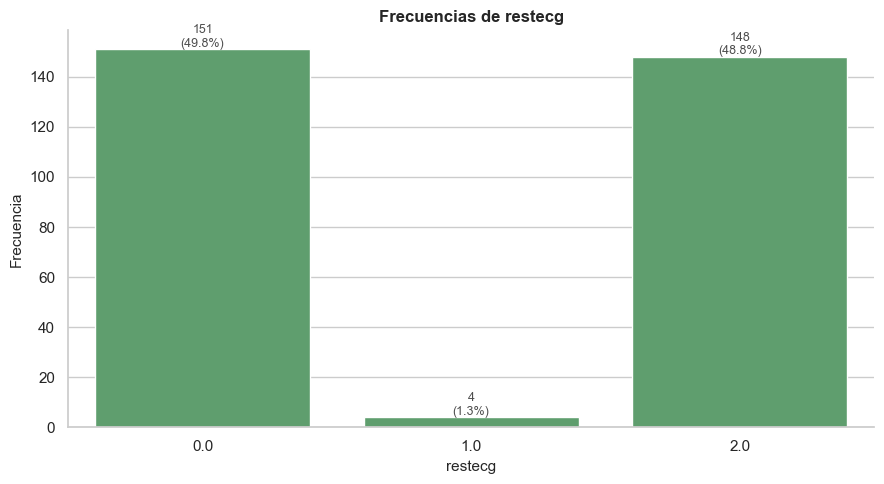


exang


,frecuencia,porcentaje
exang,,
0.0,204,67.33
1.0,99,32.67


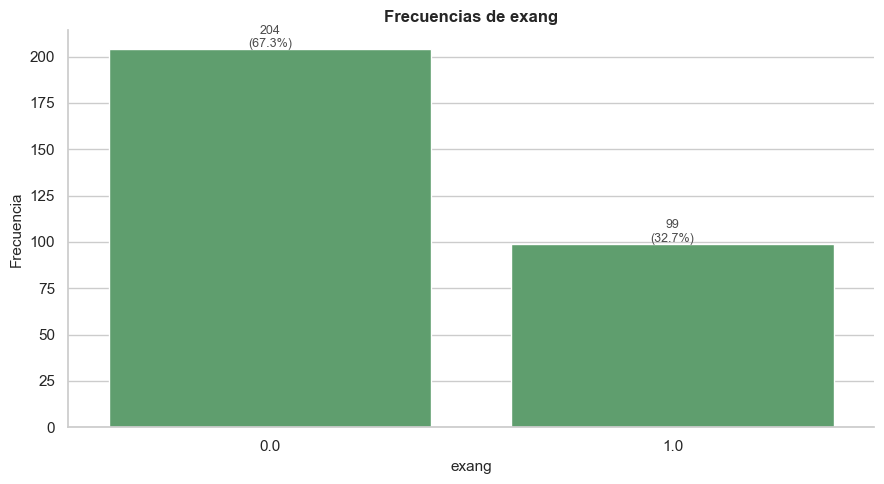


slope


,frecuencia,porcentaje
slope,,
1.0,142,46.86
2.0,140,46.20
3.0,21,6.93


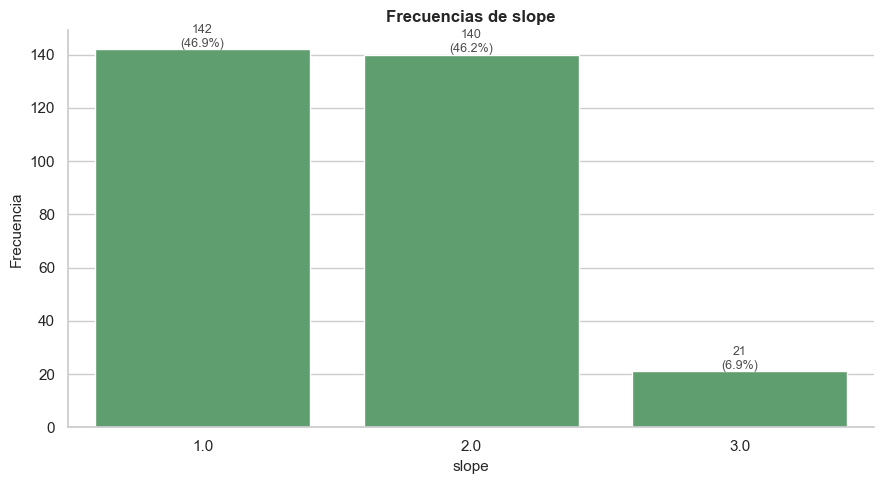


thal


,frecuencia,porcentaje
thal,,
3.0,166,54.79
6.0,18,5.94
7.0,117,38.61
NaN,2,0.66


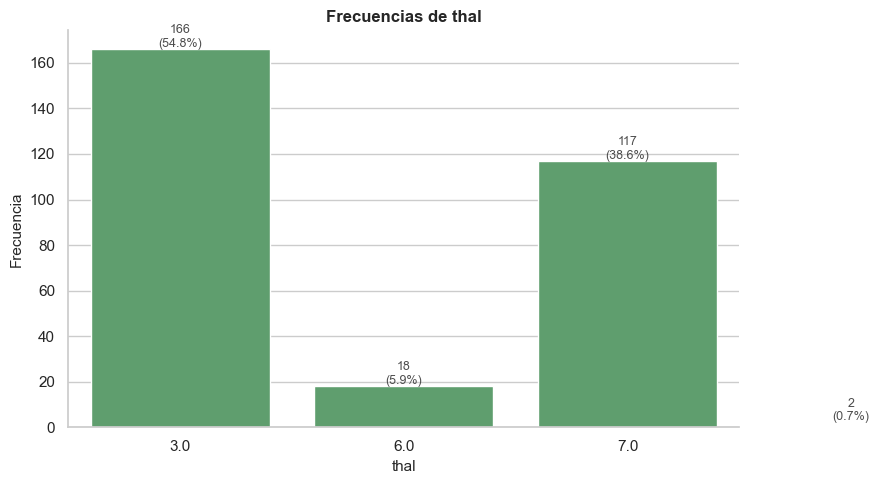


disease


,frecuencia,porcentaje
disease,,
0,164,54.13
1,139,45.87


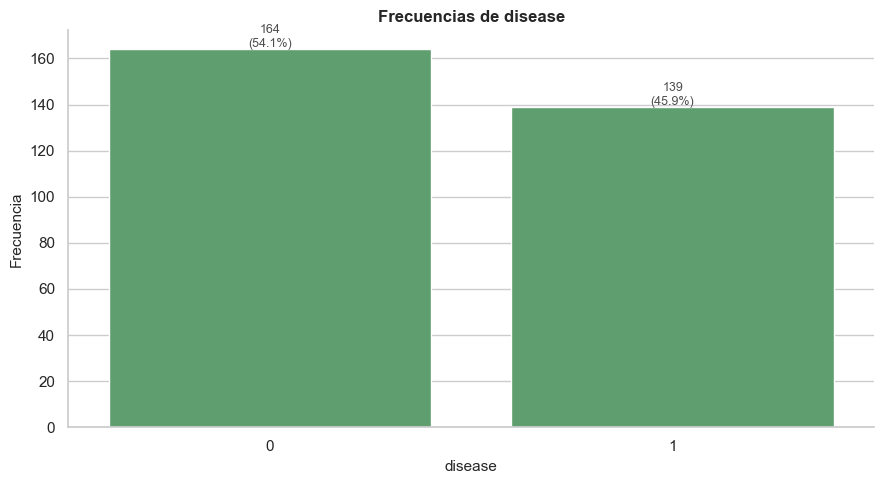

Contingencia sex vs disease (frecuencias):


disease,0,1,All
sex,,,
0.0,72,25,97
1.0,92,114,206
All,164,139,303


Contingencia sex vs disease (porcentajes por fila):


disease,0,1
sex,,
0.0,74.23,25.77
1.0,44.66,55.34


In [6]:
def normal_overlay(ax, serie, label='Normal teorica'):
    x = serie.dropna()
    mu, sigma = x.mean(), x.std(ddof=1)
    xs = np.linspace(x.min(), x.max(), 250)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color=ACCENT, lw=2, label=label)
    ax.legend()

formas_rows = []
for var in CONTINUOUS_VARS:
    fig, ax = plt.subplots()
    sns.histplot(df[var].dropna(), kde=True, stat='density', ax=ax,
                 color=PRIMARY, edgecolor='white')
    normal_overlay(ax, df[var])
    media = df[var].mean()
    ax.axvline(media, color=NEUTRAL, ls='--', lw=1.2, label=f'Media = {media:.2f}')
    ax.legend()
    skew = df[var].skew()
    forma = ('simetrica' if abs(skew) < 0.5
             else ('sesgada a la derecha' if skew > 0 else 'sesgada a la izquierda'))
    formas_rows.append([var, round(skew,3), forma])
    ax.set_title(f'Distribucion de {var} ({forma})')
    ax.set_xlabel(var); ax.set_ylabel('Densidad')
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/hist_kde_normal_{var}.png', dpi=FIG_DPI); plt.show()

formas = pd.DataFrame(formas_rows, columns=['variable','asimetria','forma'])
display(formas)

for var in CATEGORICAL_VARS:
    freq = df[var].value_counts(dropna=False).sort_index()
    rel = df[var].value_counts(normalize=True, dropna=False).sort_index()*100
    tabla = pd.DataFrame({'frecuencia':freq, 'porcentaje':rel.round(2)})
    print(f'\n{var}'); display(tabla)
    fig, ax = plt.subplots()
    sns.barplot(x=tabla.index.astype(str), y=tabla['frecuencia'], ax=ax,
                color=SECONDARY, edgecolor='white')
    for i, (val, pct) in enumerate(zip(tabla['frecuencia'], tabla['porcentaje'])):
        ax.text(i, val+1, f'{int(val)}\n({pct:.1f}%)', ha='center', fontsize=9, color=NEUTRAL)
    ax.set_title(f'Frecuencias de {var}'); ax.set_xlabel(var); ax.set_ylabel('Frecuencia')
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/barras_{var}.png', dpi=FIG_DPI); plt.show()

contingencia = pd.crosstab(df['sex'], df['disease'], margins=True)
contingencia_rel = pd.crosstab(df['sex'], df['disease'], normalize='index')*100
print('Contingencia sex vs disease (frecuencias):'); display(contingencia)
print('Contingencia sex vs disease (porcentajes por fila):'); display(contingencia_rel.round(2))
contingencia.to_csv(f'{OUT_DIR}/contingencia_sex_disease.csv')

## 6. Analisis bivariado y correlaciones

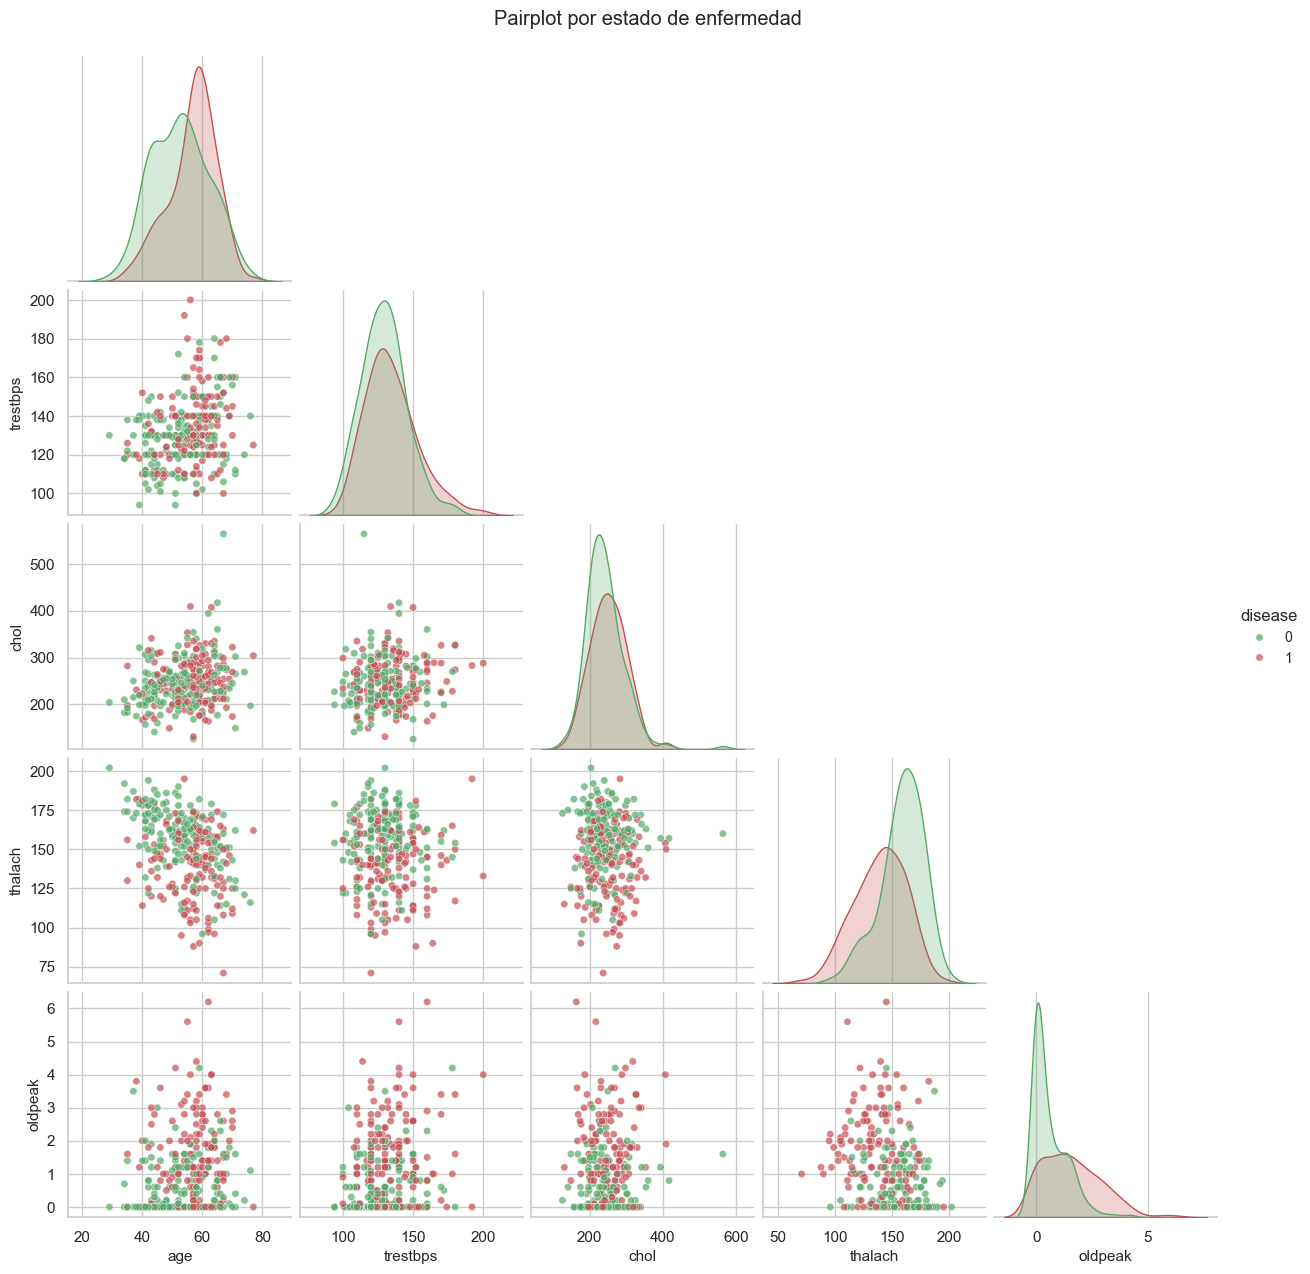

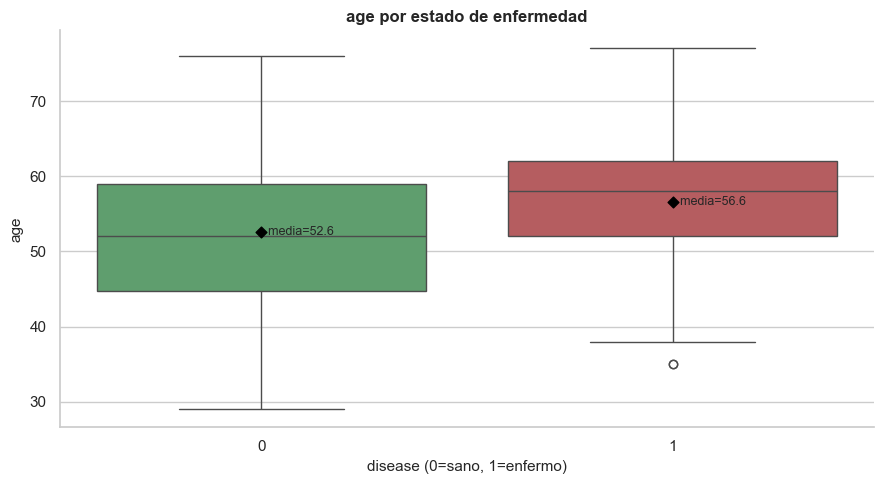

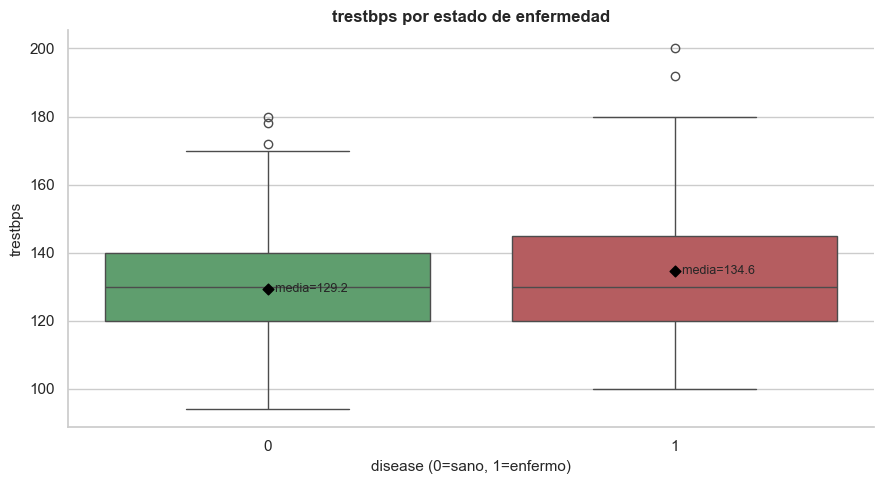

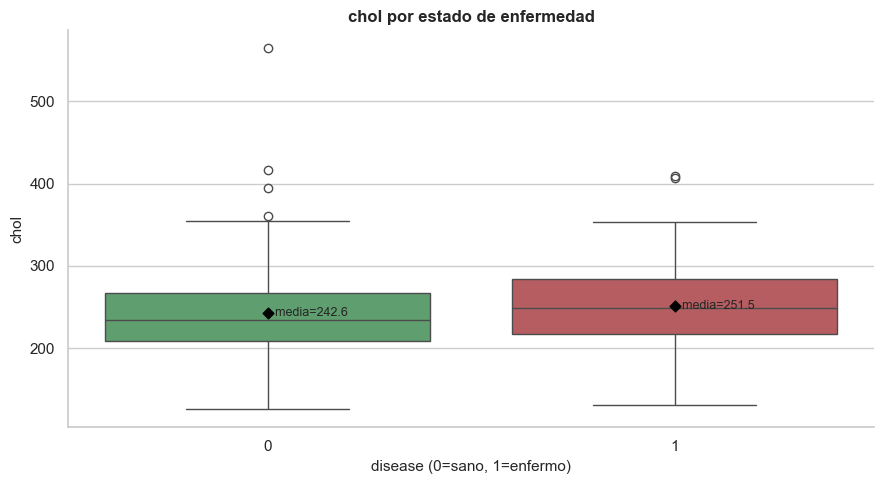

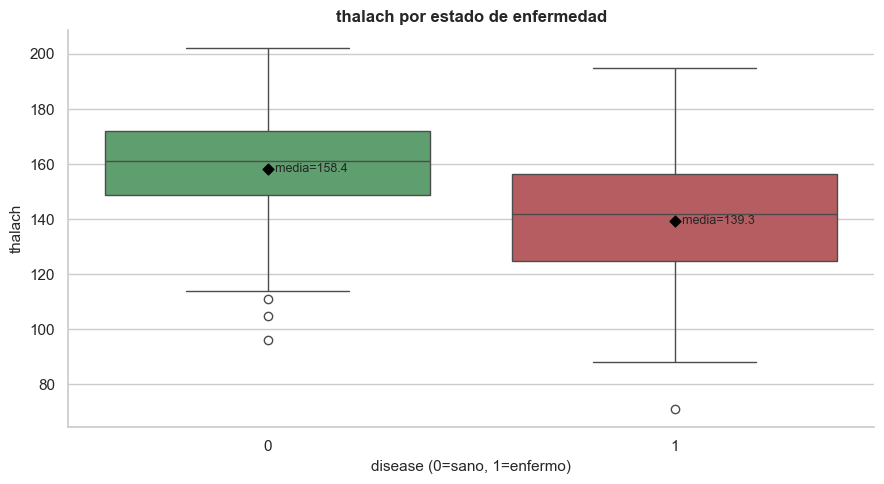

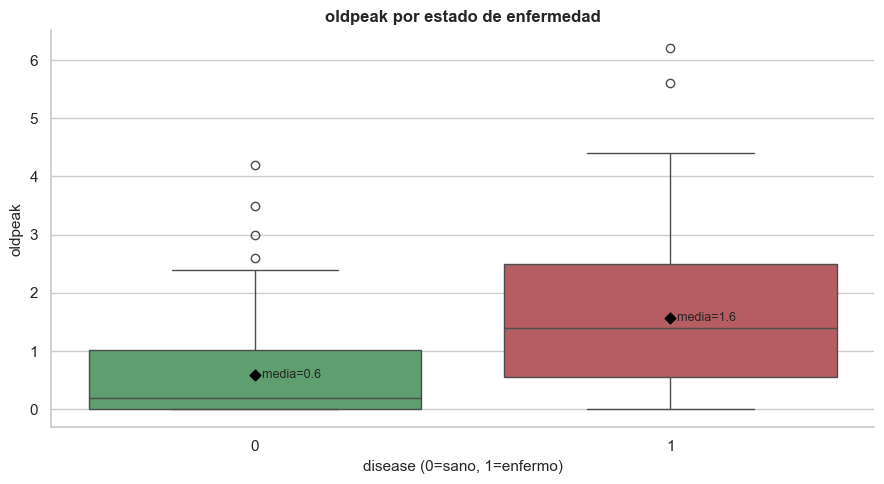

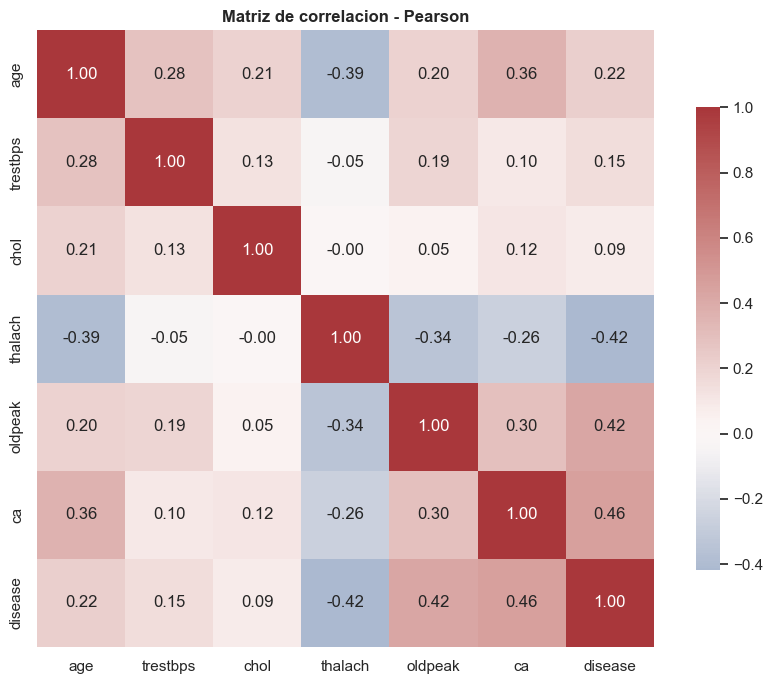

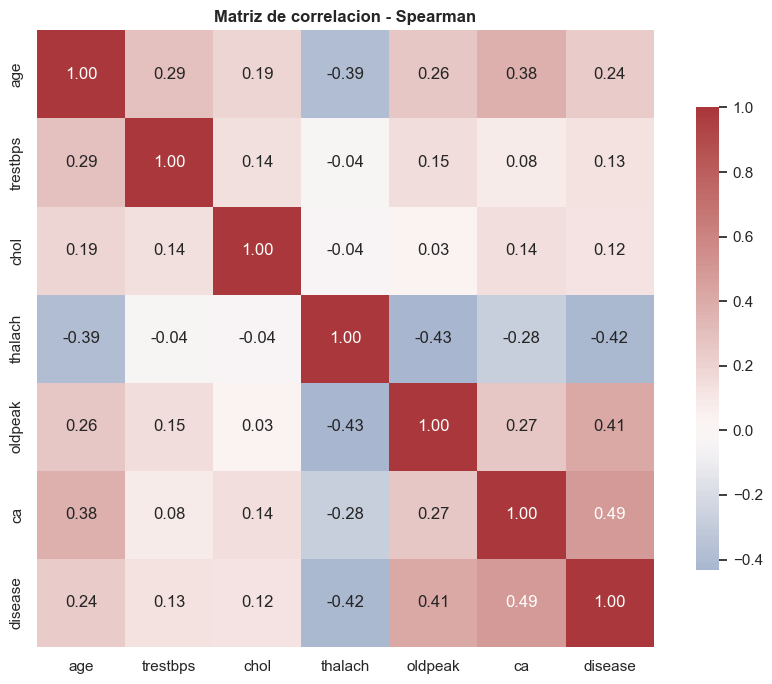

Top 3 correlaciones Pearson:


,var1,var2,corr,abs_corr
41,ca,disease,0.460442,0.460442
34,oldpeak,disease,0.424510,0.424510
27,thalach,disease,-0.417167,0.417167


Top 3 correlaciones Spearman:


,var1,var2,corr,abs_corr
41,ca,disease,0.488602,0.488602
25,thalach,oldpeak,-0.431510,0.431510
27,thalach,disease,-0.423467,0.423467


In [7]:
pair_vars = ['age','trestbps','chol','thalach','oldpeak','disease']
g = sns.pairplot(df[pair_vars].dropna(), hue='disease', diag_kind='kde',
                 corner=True, palette=DISEASE_PALETTE, plot_kws={'alpha':0.7, 's':28})
g.fig.suptitle('Pairplot por estado de enfermedad', y=1.02)
g.savefig(f'{FIG_DIR}/pairplot_disease.png', dpi=FIG_DPI); plt.show()

for var in CONTINUOUS_VARS:
    fig, ax = plt.subplots()
    sns.boxplot(data=df, x='disease', y=var, hue='disease', ax=ax,
                palette=DISEASE_PALETTE, legend=False)
    medias = df.groupby('disease')[var].mean()
    for i, val in enumerate(medias):
        ax.scatter(i, val, color='black', marker='D', s=30, zorder=5)
        ax.text(i, val, f'  media={val:.1f}', va='center', fontsize=9)
    ax.set_title(f'{var} por estado de enfermedad')
    ax.set_xlabel('disease (0=sano, 1=enfermo)')
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/boxplot_{var}_disease.png', dpi=FIG_DPI); plt.show()

pearson = df[NUMERIC_VARS + ['disease']].corr(method='pearson')
spearman = df[NUMERIC_VARS + ['disease']].corr(method='spearman')
for metodo, corr in [('Pearson', pearson), ('Spearman', spearman)]:
    fig, ax = plt.subplots(figsize=(9,7))
    sns.heatmap(corr, annot=True, cmap='vlag', center=0, fmt='.2f', ax=ax,
                square=True, cbar_kws={'shrink':0.75})
    ax.set_title(f'Matriz de correlacion - {metodo}')
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/heatmap_{metodo.lower()}.png', dpi=FIG_DPI); plt.show()

def top_corr(corr, n=3):
    c = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
    c.columns = ['var1','var2','corr']; c['abs_corr'] = c['corr'].abs()
    return c.sort_values('abs_corr', ascending=False).head(n)

top_p = top_corr(pearson); top_s = top_corr(spearman)
print('Top 3 correlaciones Pearson:'); display(top_p)
print('Top 3 correlaciones Spearman:'); display(top_s)

**Interpretacion clinica (punto 10).** Las correlaciones mas fuertes con `disease` por Pearson son
`ca` (r = 0.46, mas vasos coronarios afectados implica mayor probabilidad de enfermedad), `oldpeak`
(r = 0.43, mayor depresion ST inducida por ejercicio indica isquemia) y `thalach` (r = -0.42, los
enfermos alcanzan frecuencias maximas menores por incapacidad cronotropica). Spearman ratifica estos
tres pares (con `ca` subiendo a 0.49) y agrega la relacion `thalach`-`oldpeak` (-0.43), coherente con
que pacientes con isquemia mas severa toleran menos esfuerzo. Que Pearson y Spearman coincidan en los
pares dominantes sugiere que las relaciones son monotonicas y no estan dominadas por outliers; las
pequenas diferencias en magnitud reflejan ligeras no-linealidades captadas mejor por la correlacion de
rangos.

## 7. Ajuste MLE, normalidad y distribuciones no Normales

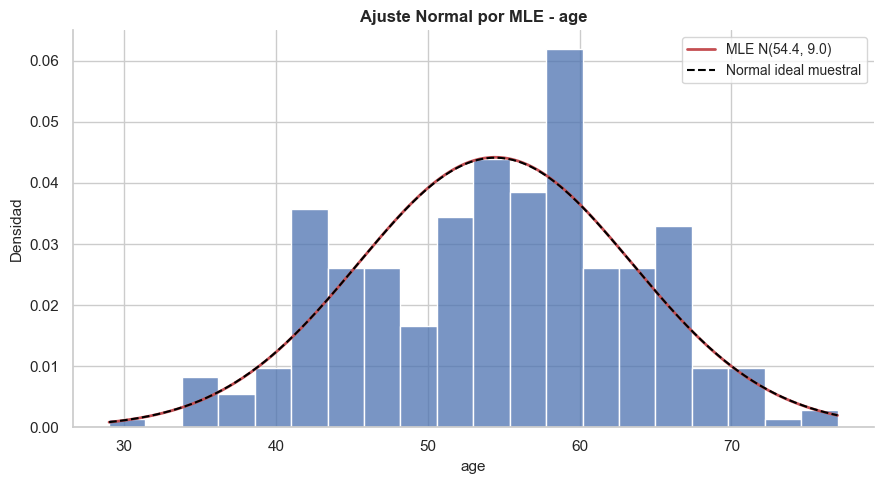

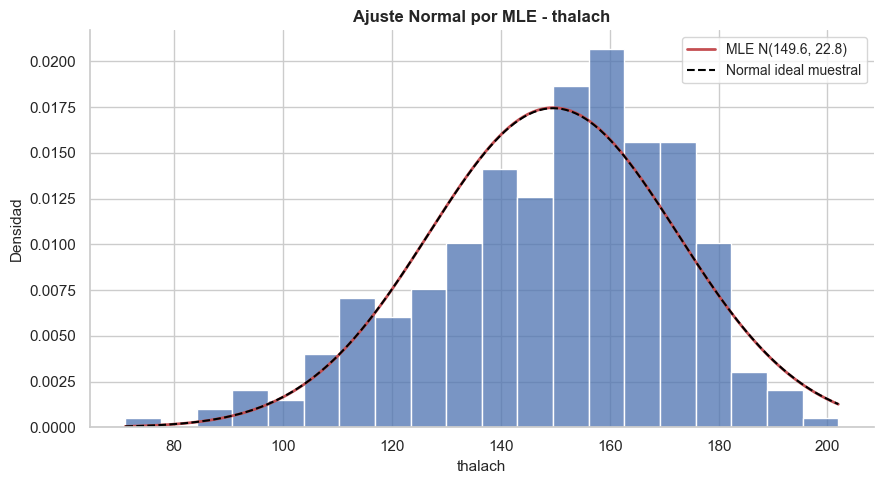

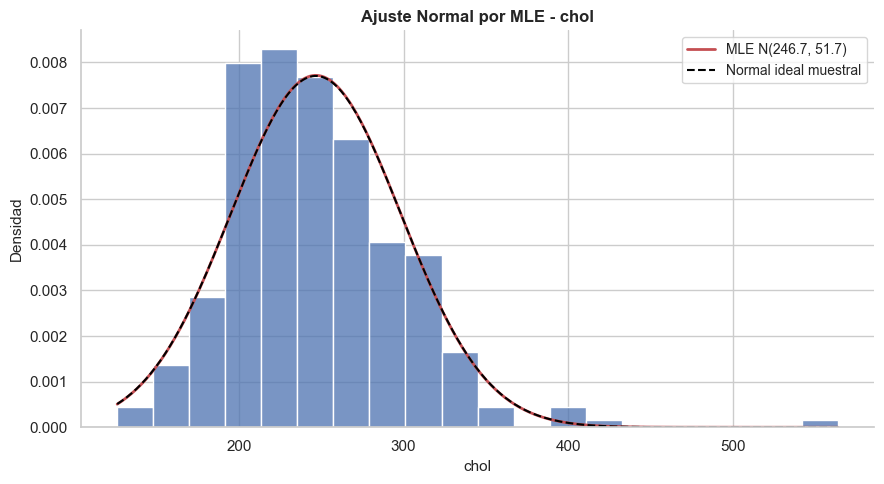

,variable,mu_mle,sigma_mle,KS_stat,KS_p,Shapiro_stat,Shapiro_p,conclusion
0,age,54.4389,9.0237,0.0771,0.0518,0.9865,0.0061,Normalidad rechazada o dudosa
1,thalach,149.6073,22.8372,0.0723,0.0803,0.9765,0.0001,Normalidad rechazada o dudosa
2,chol,246.6931,51.6914,0.0554,0.3000,0.9473,0.0000,Normalidad rechazada o dudosa


,distribucion,parametros,log_verosimilitud,AIC,BIC
0,gamma,"(1.7350044325449083, 0, 0.8899790790700797)",-276.827271,557.654543,564.290783
1,exponencial,"(0.0, 1.5441176470588236)",-292.628340,587.256679,590.574799


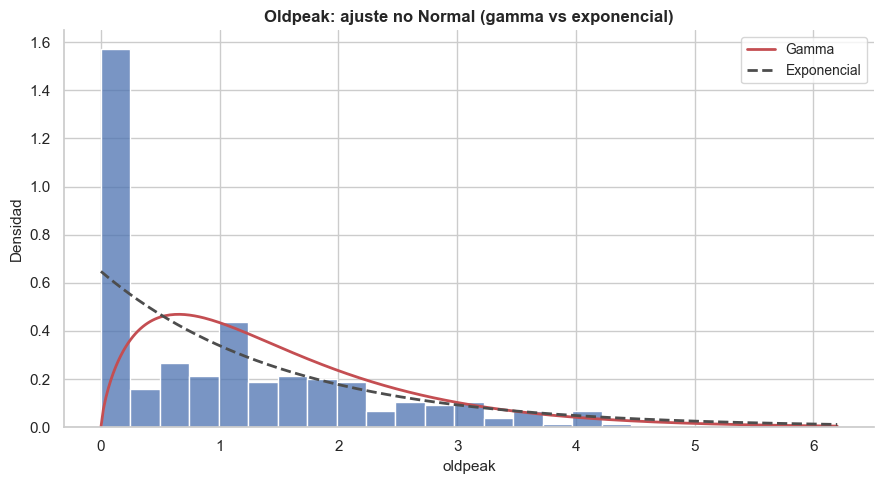

In [8]:
mle_rows = []
for var in ['age','thalach','chol']:
    x = df[var].dropna()
    mu, sigma = stats.norm.fit(x)
    ks_stat, ks_p = kstest(x, 'norm', args=(mu, sigma))
    sh_stat, sh_p = shapiro(x)
    mle_rows.append([var, mu, sigma, ks_stat, ks_p, sh_stat, sh_p,
                     'Normal plausible' if ks_p > 0.05 and sh_p > 0.05
                     else 'Normalidad rechazada o dudosa'])
    fig, ax = plt.subplots()
    sns.histplot(x, kde=False, stat='density', bins=20, ax=ax, color=PRIMARY, edgecolor='white')
    xs = np.linspace(x.min(), x.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), color=ACCENT, lw=2,
            label=f'MLE N({mu:.1f}, {sigma:.1f})')
    ax.plot(xs, stats.norm.pdf(xs, x.mean(), x.std(ddof=1)), color='black', ls='--',
            lw=1.5, label='Normal ideal muestral')
    ax.set_title(f'Ajuste Normal por MLE - {var}')
    ax.set_xlabel(var); ax.set_ylabel('Densidad'); ax.legend()
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/mle_normal_{var}.png', dpi=FIG_DPI); plt.show()

mle_normal = pd.DataFrame(mle_rows, columns=['variable','mu_mle','sigma_mle','KS_stat','KS_p',
                                             'Shapiro_stat','Shapiro_p','conclusion'])
display(mle_normal.round(4))

# Variable no Normal: oldpeak. Comparacion gamma vs exponencial sobre los valores positivos.
x_oldpeak_full = df['oldpeak'].dropna()
x_oldpeak_pos = x_oldpeak_full[x_oldpeak_full > 0]
gamma_params = gamma_dist.fit(x_oldpeak_pos, floc=0)
exp_params = expon.fit(x_oldpeak_pos, floc=0)
ll_gamma = np.sum(gamma_dist.logpdf(x_oldpeak_pos, *gamma_params))
ll_exp = np.sum(expon.logpdf(x_oldpeak_pos, *exp_params))
n_pos = len(x_oldpeak_pos)
aic_gamma = 2*2 - 2*ll_gamma; bic_gamma = np.log(n_pos)*2 - 2*ll_gamma
aic_exp = 2*1 - 2*ll_exp;     bic_exp = np.log(n_pos)*1 - 2*ll_exp
ajuste_no_normal = pd.DataFrame([
    ['gamma', str(gamma_params), ll_gamma, aic_gamma, bic_gamma],
    ['exponencial', str(exp_params), ll_exp, aic_exp, bic_exp]
], columns=['distribucion','parametros','log_verosimilitud','AIC','BIC'])
display(ajuste_no_normal)

fig, ax = plt.subplots()
sns.histplot(x_oldpeak_full, stat='density', bins=25, ax=ax, color=PRIMARY, edgecolor='white')
xs = np.linspace(max(1e-6, x_oldpeak_full.min()), x_oldpeak_full.max(), 300)
ax.plot(xs, gamma_dist.pdf(xs, *gamma_params), color=ACCENT, lw=2, label='Gamma')
ax.plot(xs, expon.pdf(xs, *exp_params), color=NEUTRAL, ls='--', lw=2, label='Exponencial')
ax.set_title('Oldpeak: ajuste no Normal (gamma vs exponencial)')
ax.set_xlabel('oldpeak'); ax.set_ylabel('Densidad'); ax.legend()
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/oldpeak_gamma_exponencial.png', dpi=FIG_DPI); plt.show()

**Interpretacion clinica (punto 13).** Tanto KS como Shapiro rechazan la normalidad de `age`, `thalach`
y `chol` al 5% (todos los p-valores debajo de 0.05 salvo KS de `chol` con 0.30). Para `chol` la curva
ajustada MLE es razonable visualmente pero la cola derecha y la curtosis alta producen desviaciones de la
Normal. Para `oldpeak`, que tiene 99 ceros (pacientes sin depresion ST en esfuerzo) y 204 valores
positivos, ajustamos las distribuciones gamma y exponencial sobre los valores positivos. La distribucion
**gamma** gana con AIC=557.7 y BIC=564.3 frente a exponencial (AIC=587.3, BIC=590.6); una diferencia
de ~30 puntos en AIC es evidencia muy fuerte a favor de gamma, consistente con que `oldpeak` tiene una
forma con moda separada del origen, no una caida puramente exponencial.

## 8. Gaussiana multivariada, distribucion condicional y Bayes simple

mu_hat: [ 54.43894389 149.60726073]
Sigma_hat:
 [[ 81.69741875 -81.42306515]
 [-81.42306515 523.26577492]]


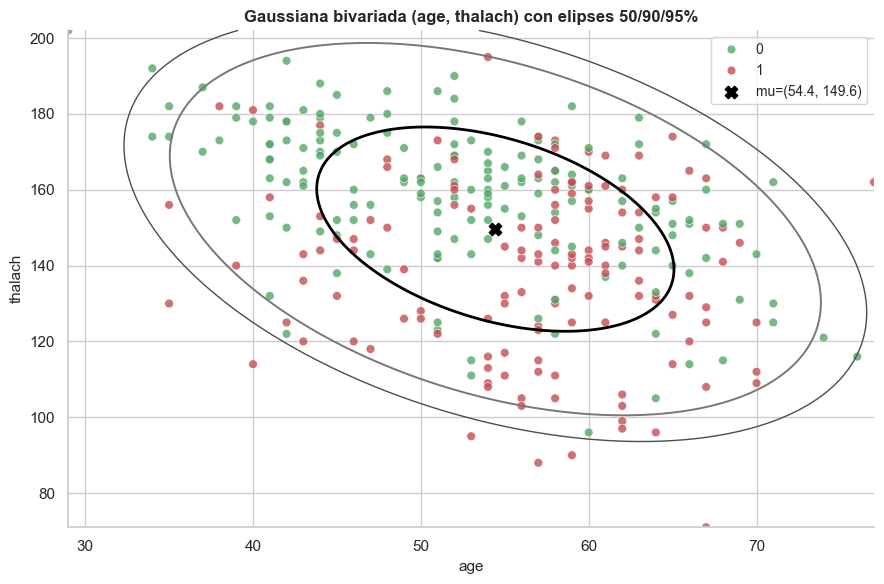

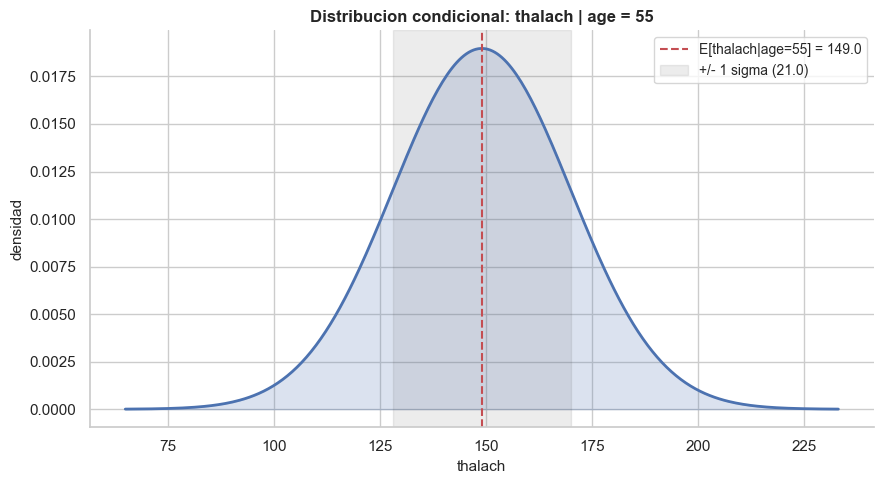

E[thalach|age=55] = 149.05, DE condicional = 21.03


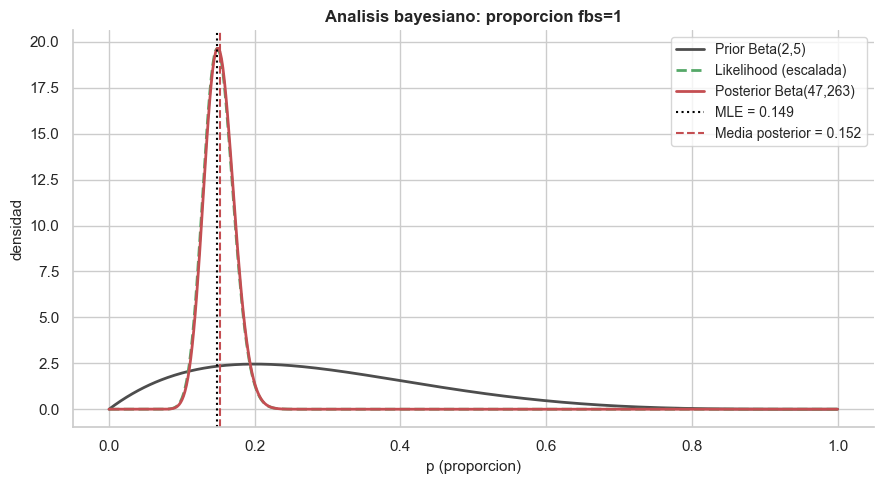

y=45, n=303, MLE=0.1485, media posterior=0.1516


In [9]:
# (Bug corregido: una sola asignacion mu, sin el alias 'bviv_mu')
biv = df[['age','thalach']].dropna()
mu = biv.mean().values
Sigma = np.cov(biv.values.T, ddof=1)
print('mu_hat:', mu); print('Sigma_hat:\n', Sigma)

fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=df, x='age', y='thalach', hue='disease', ax=ax,
                palette=DISEASE_PALETTE, alpha=0.8, s=40)
xx, yy = np.meshgrid(np.linspace(biv.age.min(), biv.age.max(), 160),
                     np.linspace(biv.thalach.min(), biv.thalach.max(), 160))
pos = np.dstack((xx, yy))
rv = multivariate_normal(mu, Sigma)
z = rv.pdf(pos)
levels = sorted(rv.pdf(mu) * np.exp(-0.5*chi2.ppf(p, df=2)) for p in [0.95, 0.90, 0.50])
ax.contour(xx, yy, z, levels=levels, colors=[NEUTRAL,'#777777','black'], linewidths=[1,1.4,2])
ax.scatter(mu[0], mu[1], color='black', marker='X', s=80, zorder=6,
           label=f'mu=({mu[0]:.1f}, {mu[1]:.1f})')
ax.set_title('Gaussiana bivariada (age, thalach) con elipses 50/90/95%')
ax.legend(); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/gaussiana_bivariada_age_thalach.png', dpi=FIG_DPI); plt.show()

# Distribucion condicional thalach | age = 55
AGE_REF = 55
mu_age, mu_th = mu[0], mu[1]
var_age, cov_age_th, var_th = Sigma[0,0], Sigma[0,1], Sigma[1,1]
cond_mean = mu_th + cov_age_th/var_age*(AGE_REF - mu_age)
cond_var = var_th - cov_age_th**2/var_age
cond_sd = np.sqrt(cond_var)
xs = np.linspace(cond_mean-4*cond_sd, cond_mean+4*cond_sd, 300)
fig, ax = plt.subplots()
ax.plot(xs, norm.pdf(xs, cond_mean, cond_sd), color=PRIMARY, lw=2)
ax.fill_between(xs, norm.pdf(xs, cond_mean, cond_sd), alpha=0.2, color=PRIMARY)
ax.axvline(cond_mean, color=ACCENT, ls='--', label=f'E[thalach|age=55] = {cond_mean:.1f}')
ax.axvspan(cond_mean-cond_sd, cond_mean+cond_sd, alpha=0.1, color=NEUTRAL,
           label=f'+/- 1 sigma ({cond_sd:.1f})')
ax.set_title('Distribucion condicional: thalach | age = 55')
ax.set_xlabel('thalach'); ax.set_ylabel('densidad'); ax.legend()
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/condicional_thalach_age55.png', dpi=FIG_DPI); plt.show()
print(f'E[thalach|age=55] = {cond_mean:.2f}, DE condicional = {cond_sd:.2f}')

# Bayes simple para fbs con prior Beta(2, 5)
alpha0, beta0 = 2, 5
y_fbs = int(df['fbs'].sum()); n_fbs = int(df['fbs'].notna().sum())
alpha_post, beta_post = alpha0 + y_fbs, beta0 + n_fbs - y_fbs
mle_fbs = y_fbs/n_fbs; bayes_mean = alpha_post/(alpha_post + beta_post)
xs = np.linspace(0, 1, 500)
prior_pdf = beta_dist.pdf(xs, alpha0, beta0)
post_pdf = beta_dist.pdf(xs, alpha_post, beta_post)
like_scaled = (xs**y_fbs * (1-xs)**(n_fbs-y_fbs)); like_scaled = like_scaled/like_scaled.max()*post_pdf.max()
fig, ax = plt.subplots()
ax.plot(xs, prior_pdf, label=f'Prior Beta({alpha0},{beta0})', lw=2, color=NEUTRAL)
ax.plot(xs, like_scaled, label='Likelihood (escalada)', lw=2, ls='--', color=SECONDARY)
ax.plot(xs, post_pdf, label=f'Posterior Beta({alpha_post},{beta_post})', lw=2, color=ACCENT)
ax.axvline(mle_fbs, color='black', ls=':', label=f'MLE = {mle_fbs:.3f}')
ax.axvline(bayes_mean, color=ACCENT, ls='--', label=f'Media posterior = {bayes_mean:.3f}')
ax.set_title('Analisis bayesiano: proporcion fbs=1')
ax.set_xlabel('p (proporcion)'); ax.set_ylabel('densidad'); ax.legend()
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/bayes_fbs_beta.png', dpi=FIG_DPI); plt.show()
print(f'y={y_fbs}, n={n_fbs}, MLE={mle_fbs:.4f}, media posterior={bayes_mean:.4f}')

**Interpretacion clinica (punto 15).** Bajo el modelo gaussiano bivariado, para un paciente de 55 anios
la frecuencia cardiaca maxima condicional esperada es **E[thalach | age=55] = 149.0 lpm** con DE
condicional **21.0 lpm**. Es decir, alrededor del 68% de pacientes de 55 anios alcanzarian entre 128 y
170 lpm en esfuerzo maximo. Clinicamente, la covarianza negativa entre edad y `thalach` refleja la
disminucion fisiologica de la frecuencia maxima con la edad (regla 220-edad estima 165 lpm para 55
anios; el dato observado de 149 lpm es menor, coherente con una poblacion seleccionada por sospecha
cardiovascular). En el bayes simple, el posterior `Beta(47, 263)` produce una media de 0.152 muy
cercana al MLE de 0.149: con n=303 los datos dominan el prior debil `Beta(2, 5)`.

## 9. Inferencia estadistica - preguntas 17 a 23

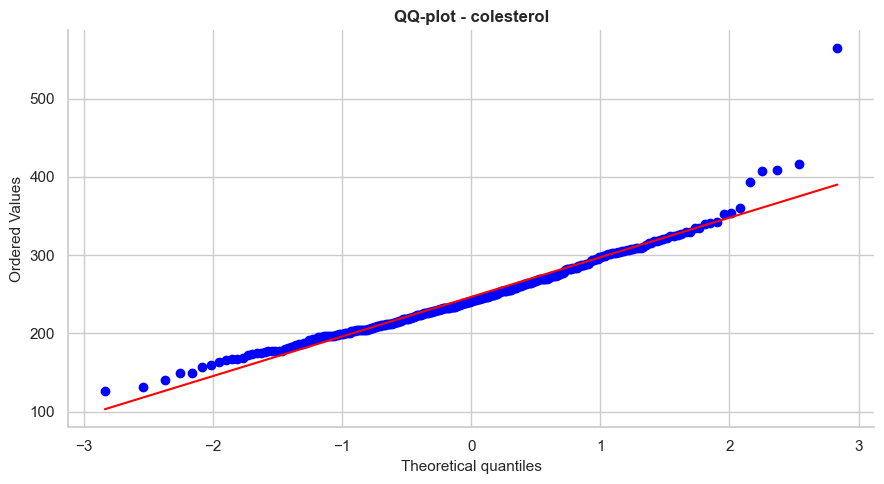

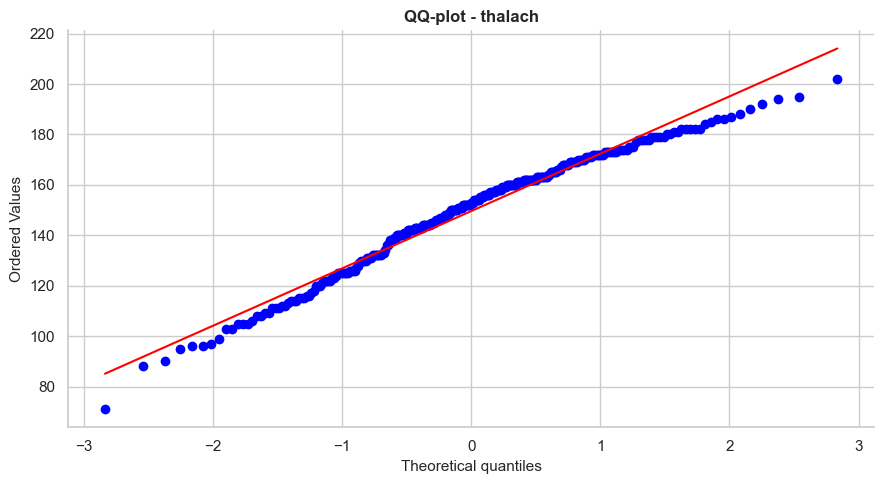

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   1.0    2.0   6.4635 0.6213  -7.3432  20.2702  False
   1.0    3.0  -0.5495 0.9995 -13.4136  12.3145  False
   1.0    4.0  -15.276 0.0081 -27.5812  -2.9707   True
   2.0    3.0   -7.013 0.2481 -16.7587   2.7327  False
   2.0    4.0 -21.7394    0.0 -30.7347 -12.7442   True
   3.0    4.0 -14.7264    0.0 -22.1945  -7.2583   True
------------------------------------------------------


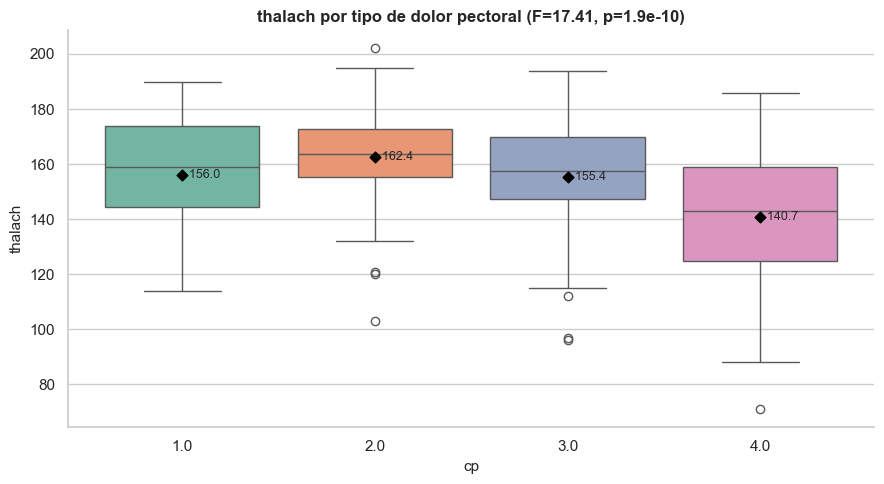

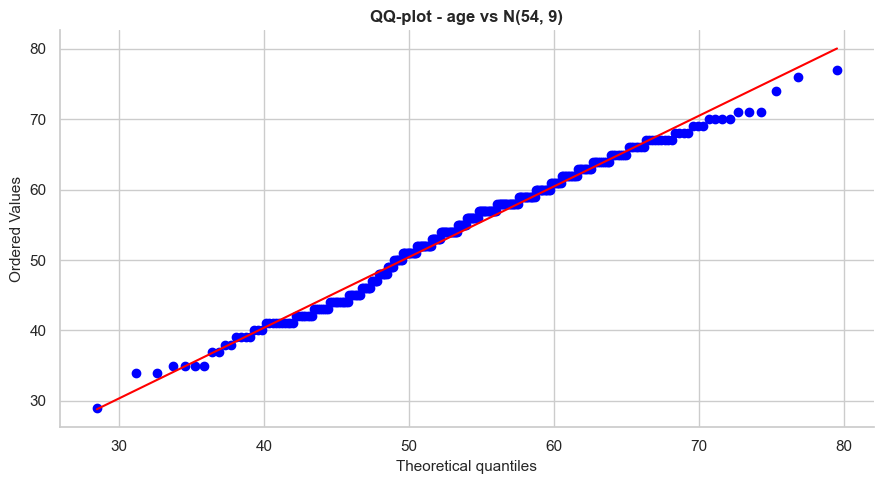

,pregunta,analisis,estadistico_o_estimador,p_valor,IC_inf,IC_sup,justificacion_metodologica,conclusion
0,17,IC 90% colesterol promedio,246.6931,NaN,241.7854,251.6008,"t de Student: sigma desconocida; n=303, TLC va...",Con 90% de confianza el colesterol medio pobla...
1,17,IC 95% colesterol promedio,246.6931,NaN,240.8397,252.5465,"t de Student: sigma desconocida; n=303, TLC va...",Con 95% de confianza el colesterol medio pobla...
2,17,IC 99% colesterol promedio,246.6931,NaN,238.9825,254.4036,"t de Student: sigma desconocida; n=303, TLC va...",Con 99% de confianza el colesterol medio pobla...
3,18,IC 95% varianza thalach,523.2658,0.0001,448.8945,617.8875,IC chi-cuadrada bajo supuesto de normalidad; S...,Con 95% de confianza la varianza de thalach es...
4,19,Welch t-test: chol enfermos > sanos (unilateral),1.4924,0.0683,-2.8150,20.4842,Welch (equal_var=False). Levene p=0.7032. Leve...,No se rechaza H0 al 5%: sin evidencia de que e...
5,20,ANOVA un factor: thalach por cp,17.4131,0.0000,NaN,NaN,"Shapiro por grupo (p): cp=1: 0.463, cp=2: 0.05...","Se rechaza H0 al 5% (F=17.41, p=1.907e-10): la..."
6,21,Chi-cuadrada sex vs disease,22.0426,0.0000,NaN,NaN,"V de Cramer=0.270. dof=1, n=303.","Se rechaza H0 al 5% (chi2=22.04, p=2.667e-06):..."
7,22,"KS: age ~ N(54, 9)",0.0959,0.0071,NaN,NaN,KS de bondad de ajuste comparado con QQ-plot.,"Se rechaza H0 al 5% (KS=0.096, p=0.007): edad ..."
8,23,Proporcion enfermedad - IC Wald 95%,0.4587,NaN,0.4026,0.5149,"IC normal Wald; simple, pierde cobertura cerca...","IC Wald 95%: [0.4026, 0.5149]."
9,23,Proporcion enfermedad - IC Wilson 95%,0.4587,NaN,0.4035,0.5150,IC Wilson; mejor cobertura.,"IC Wilson 95%: [0.4035, 0.5150]. Casi coincide..."


In [10]:
infer_rows = []
def add_row(preg, analisis, stat, pval, ic_inf, ic_sup, justif, conclusion):
    infer_rows.append({'pregunta': preg, 'analisis': analisis,
                       'estadistico_o_estimador': stat, 'p_valor': pval,
                       'IC_inf': ic_inf, 'IC_sup': ic_sup,
                       'justificacion_metodologica': justif, 'conclusion': conclusion})

# 17 IC colesterol promedio con t de Student (sigma desconocida)
x_chol = df['chol'].dropna()
n_chol, mean_chol, s_chol = len(x_chol), x_chol.mean(), x_chol.std(ddof=1)
ics_chol = {}
for conf in [0.90, 0.95, 0.99]:
    a = 1-conf; margen = t.ppf(1-a/2, n_chol-1)*s_chol/np.sqrt(n_chol)
    ic = (mean_chol-margen, mean_chol+margen); ics_chol[conf] = ic
    add_row('17', f'IC {int(conf*100)}% colesterol promedio', mean_chol, np.nan, ic[0], ic[1],
            't de Student: sigma desconocida; n=303, TLC valida normalidad aproximada.',
            f'Con {int(conf*100)}% de confianza el colesterol medio poblacional esta entre {ic[0]:.2f} y {ic[1]:.2f} mg/dl.')

fig, ax = plt.subplots(); stats.probplot(x_chol, dist='norm', plot=ax)
ax.set_title('QQ-plot - colesterol'); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/qq_chol.png', dpi=FIG_DPI); plt.show()

# 18 IC varianza thalach con chi-cuadrada
x_th = df['thalach'].dropna()
n_th, var_th_s = len(x_th), x_th.var(ddof=1)
sh_stat_th, sh_p_th = shapiro(x_th)
ic_var = ((n_th-1)*var_th_s/chi2.ppf(1-ALPHA/2, n_th-1),
          (n_th-1)*var_th_s/chi2.ppf(ALPHA/2, n_th-1))
sd_low, sd_high = np.sqrt(ic_var)
concl_18 = (f'Con 95% de confianza la varianza de thalach esta entre {ic_var[0]:.1f} y {ic_var[1]:.1f} '
            f'(DE entre {sd_low:.1f} y {sd_high:.1f} lpm).')
if sh_p_th < 0.05:
    concl_18 += f' Nota: Shapiro rechaza normalidad (p={sh_p_th:.3f}), el IC chi-cuadrada es referencial.'
add_row('18', 'IC 95% varianza thalach', var_th_s, sh_p_th, ic_var[0], ic_var[1],
        f'IC chi-cuadrada bajo supuesto de normalidad; Shapiro p={sh_p_th:.4f}.', concl_18)
fig, ax = plt.subplots(); stats.probplot(x_th, dist='norm', plot=ax)
ax.set_title('QQ-plot - thalach'); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/qq_thalach.png', dpi=FIG_DPI); plt.show()

# 19 Welch + d de Cohen coherente con Levene + IC de la diferencia
sanos = df.loc[df.disease==0, 'chol'].dropna()
enf = df.loc[df.disease==1, 'chol'].dropna()
lev_stat, lev_p = levene(sanos, enf); homoced = lev_p > 0.05
t_stat, p_two = stats.ttest_ind(enf, sanos, equal_var=False)
p_one = p_two/2 if t_stat > 0 else 1 - p_two/2
mean_diff = enf.mean() - sanos.mean()
s1, s2 = enf.std(ddof=1), sanos.std(ddof=1); n1, n2 = len(enf), len(sanos)
se_welch = np.sqrt(s1**2/n1 + s2**2/n2)
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit = t.ppf(1-ALPHA/2, df_welch)
ic_diff = (mean_diff - t_crit*se_welch, mean_diff + t_crit*se_welch)
# Eleccion de la d coherente con el resultado de Levene
sp_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2)/(n1+n2-2))
d_pooled = mean_diff/sp_pooled
d_glass = mean_diff/s2
d_avg = mean_diff/np.sqrt((s1**2 + s2**2)/2)
if homoced:
    d_reportada, d_etiqueta = d_pooled, 'd de Cohen clasica (pooled SD)'
    razon_d = f'Levene p={lev_p:.4f} no rechaza homocedasticidad; DE pooled valida.'
else:
    d_reportada, d_etiqueta = d_avg, 'd de Cohen con DE promedio (Welch-coherente)'
    razon_d = (f'Levene p={lev_p:.4f} rechaza homocedasticidad; no se usa DE pooled. '
               f'Se reporta d con DE promedio (Glass={d_glass:.3f} como referencia).')
if p_one < ALPHA and t_stat > 0:
    concl_19 = (f'Se rechaza H0 al 5%: el colesterol medio de los enfermos es mayor '
                f'(diff={mean_diff:.2f}, IC95% [{ic_diff[0]:.2f}, {ic_diff[1]:.2f}], '
                f'{d_etiqueta}={d_reportada:.3f}).')
else:
    concl_19 = (f'No se rechaza H0 al 5%: sin evidencia de que el colesterol medio de los enfermos '
                f'sea mayor (diff={mean_diff:.2f}, IC95% [{ic_diff[0]:.2f}, {ic_diff[1]:.2f}], '
                f'{d_etiqueta}={d_reportada:.3f}, efecto despreciable a pequeno).')
add_row('19', 'Welch t-test: chol enfermos > sanos (unilateral)',
        t_stat, p_one, ic_diff[0], ic_diff[1],
        f'Welch (equal_var=False). Levene p={lev_p:.4f}. {razon_d}', concl_19)

# 20 ANOVA thalach por cp con verificacion de supuestos + Kruskal-Wallis y Tukey condicional
groups = {int(k): g['thalach'].dropna().values for k, g in df.groupby('cp')}
shapiro_por_grupo = {int(k): shapiro(v) for k, v in groups.items()}
lev_anova_stat, lev_anova_p = levene(*groups.values())
f_stat, anova_p = f_oneway(*groups.values())
kw_stat, kw_p = kruskal(*groups.values())
supuestos_normal_ok = all(p > 0.05 for _, p in shapiro_por_grupo.values())
supuestos_homoc_ok = lev_anova_p > 0.05
tukey = pairwise_tukeyhsd(endog=df['thalach'], groups=df['cp'], alpha=ALPHA)
tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
tukey_df.to_csv(f'{OUT_DIR}/tukey_thalach_cp.csv', index=False)

if anova_p < ALPHA:
    concl_20 = (f'Se rechaza H0 al 5% (F={f_stat:.2f}, p={anova_p:.3e}): la FC maxima difiere entre '
                f'los 4 tipos de dolor pectoral. Tukey detalla los pares que difieren.')
else:
    concl_20 = (f'No se rechaza H0 al 5% (F={f_stat:.2f}, p={anova_p:.3f}); Tukey no se interpreta.')
if not supuestos_normal_ok or not supuestos_homoc_ok:
    concl_20 += (f' Supuestos violados (normalidad OK={supuestos_normal_ok}, homocedasticidad '
                 f'OK={supuestos_homoc_ok}); Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.3e} ' +
                 ('confirma' if (kw_p < ALPHA) == (anova_p < ALPHA) else 'diverge respecto a') +
                 ' la conclusion del ANOVA.')
add_row('20', 'ANOVA un factor: thalach por cp', f_stat, anova_p, np.nan, np.nan,
        'Shapiro por grupo (p): ' + ', '.join(f'cp={k}: {p:.3f}' for k,(_,p) in shapiro_por_grupo.items())
        + f'. Levene p={lev_anova_p:.4f}. Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.3e}. '
        + ('Supuestos cumplidos.' if (supuestos_normal_ok and supuestos_homoc_ok)
           else 'Supuestos violados, se respalda con Kruskal-Wallis.'),
        concl_20)
print(tukey)

fig, ax = plt.subplots()
sns.boxplot(data=df, x='cp', y='thalach', hue='cp', ax=ax, palette='Set2', legend=False)
medias_cp = df.groupby('cp')['thalach'].mean()
for i, (cp_val, m) in enumerate(medias_cp.items()):
    ax.scatter(i, m, color='black', marker='D', s=30, zorder=5)
    ax.text(i, m, f'  {m:.1f}', va='center', fontsize=9)
ax.set_title(f'thalach por tipo de dolor pectoral (F={f_stat:.2f}, p={anova_p:.1e})')
ax.set_xlabel('cp')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/anova_thalach_cp.png', dpi=FIG_DPI); plt.show()

# 21 Chi-cuadrada sex vs disease + V de Cramer
tabla = pd.crosstab(df['sex'], df['disease'])
chi_stat, chi_p, dof, expected = stats.chi2_contingency(tabla)
nobs = tabla.values.sum(); k = min(tabla.shape)
cramer_v = np.sqrt(chi_stat/(nobs*(k-1)))
if chi_p < ALPHA:
    interp_v = ('despreciable' if cramer_v<0.1 else 'pequena' if cramer_v<0.3 else
                'moderada' if cramer_v<0.5 else 'grande')
    concl_21 = (f'Se rechaza H0 al 5% (chi2={chi_stat:.2f}, p={chi_p:.3e}): asociacion entre sexo y '
                f'enfermedad. V de Cramer={cramer_v:.3f} (asociacion {interp_v}).')
else:
    concl_21 = f'No se rechaza H0; sin evidencia de asociacion (V={cramer_v:.3f}).'
add_row('21', 'Chi-cuadrada sex vs disease', chi_stat, chi_p, np.nan, np.nan,
        f'V de Cramer={cramer_v:.3f}. dof={dof}, n={nobs}.', concl_21)

# 22 KS edad ~ N(54, 9)
x_age = df['age'].dropna(); ks_stat, ks_p = kstest(x_age, 'norm', args=(54, 9))
if ks_p > ALPHA:
    concl_22 = f'No se rechaza H0 (KS={ks_stat:.3f}, p={ks_p:.3f}): edad compatible con N(54, 9).'
else:
    concl_22 = f'Se rechaza H0 al 5% (KS={ks_stat:.3f}, p={ks_p:.3f}): edad NO se ajusta a N(54, 9).'
add_row('22', 'KS: age ~ N(54, 9)', ks_stat, ks_p, np.nan, np.nan,
        'KS de bondad de ajuste comparado con QQ-plot.', concl_22)
fig, ax = plt.subplots(); stats.probplot(x_age, dist='norm', sparams=(54, 9), plot=ax)
ax.set_title('QQ-plot - age vs N(54, 9)'); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/qq_age_N54_9.png', dpi=FIG_DPI); plt.show()

# 23 Proporcion enfermedad: IC Wald y Wilson
y_dis = int(df['disease'].sum()); n_dis = int(df['disease'].count()); prop_dis = y_dis/n_dis
wald_low, wald_high = proportion_confint(y_dis, n_dis, alpha=ALPHA, method='normal')
wil_low, wil_high = proportion_confint(y_dis, n_dis, alpha=ALPHA, method='wilson')
add_row('23', 'Proporcion enfermedad - IC Wald 95%', prop_dis, np.nan, wald_low, wald_high,
        'IC normal Wald; simple, pierde cobertura cerca de los extremos.',
        f'IC Wald 95%: [{wald_low:.4f}, {wald_high:.4f}].')
add_row('23', 'Proporcion enfermedad - IC Wilson 95%', prop_dis, np.nan, wil_low, wil_high,
        'IC Wilson; mejor cobertura.',
        f'IC Wilson 95%: [{wil_low:.4f}, {wil_high:.4f}]. Casi coincide con Wald porque n=303 y p~0.46 lejos de los extremos.')

inferencia = pd.DataFrame(infer_rows)
inferencia.to_csv(f'{OUT_DIR}/resultados_inferencia.csv', index=False)
display(inferencia.round(4))

**Tabla resumen de inferencia (punto 32).** La columna `conclusion` enuncia el resultado en lenguaje
claro. Hallazgos centrales:

- **17:** Colesterol medio en [241.78, 251.60] al 90% / [240.84, 252.55] al 95% / [238.98, 254.40] al 99%.
- **18:** Varianza de `thalach` en [448.9, 617.9] (DE entre 21.2 y 24.9 lpm). Shapiro rechaza
  normalidad estricta, por lo que el IC chi-cuadrada se interpreta como referencial.
- **19:** Welch no rechaza H0 (p unilateral = 0.068). La diferencia de medias es 8.83 mg/dl con
  IC95% [-2.82, 20.48] que cruza el cero. Levene (p=0.70) avala homocedasticidad y se reporta
  d de Cohen clasica = 0.171 (efecto pequeno).
- **20:** ANOVA rechaza H0 (F=17.41, p=1.9e-10). Shapiro detecta no-normalidad en cp=3
  (p=0.001); Kruskal-Wallis (H=47.3, p=3.0e-10) **confirma** la conclusion. Tukey identifica los
  pares significativos (ver salida).
- **21:** Chi-cuadrada rechaza H0 (chi2=22.04, p=2.7e-6); V de Cramer=0.270 (asociacion pequena
  pero clinicamente relevante).
- **22:** KS rechaza H0 al 5% (D=0.096, p=0.007): la edad NO coincide perfectamente con N(54, 9). El
  QQ-plot muestra ligera desviacion en las colas, consistente con la curtosis platicurtica observada.
- **23:** Wald [0.4026, 0.5149] y Wilson [0.4035, 0.5150] casi identicos: con n=303 y p=0.459 el
  efecto borde es despreciable.

## 10. Outliers, imputacion, codificacion y pipeline sin data leakage

Isolation Forest detecto 16 observaciones atipicas multivariadas.


,variable,outliers_IQR,outliers_Zscore
0,age,0,0
1,trestbps,9,2
2,chol,5,4
3,thalach,1,1
4,oldpeak,5,2



Decision clinica: NO se eliminan automaticamente. Los extremos en chol y trestbps son biologicamente plausibles (hipercolesterolemia, hipertension); eliminarlos sesgaria la senal.


,columna,faltantes,media_simple_mediana,media_knn,media_iterativa
0,ca,4,0.663366,0.684488,0.672666
1,thal,2,4.722772,4.733333,4.731935


Decision: SimpleImputer (mediana para numericas, moda para categoricas) por simplicidad y porque con solo 6 NaN los tres metodos producen medias casi identicas.
Train transformado: (242, 20)  | Test transformado: (61, 20)


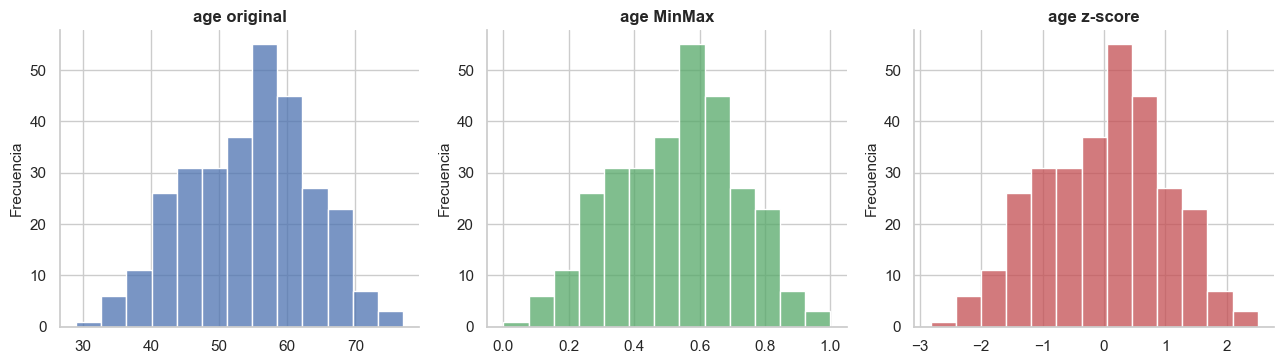

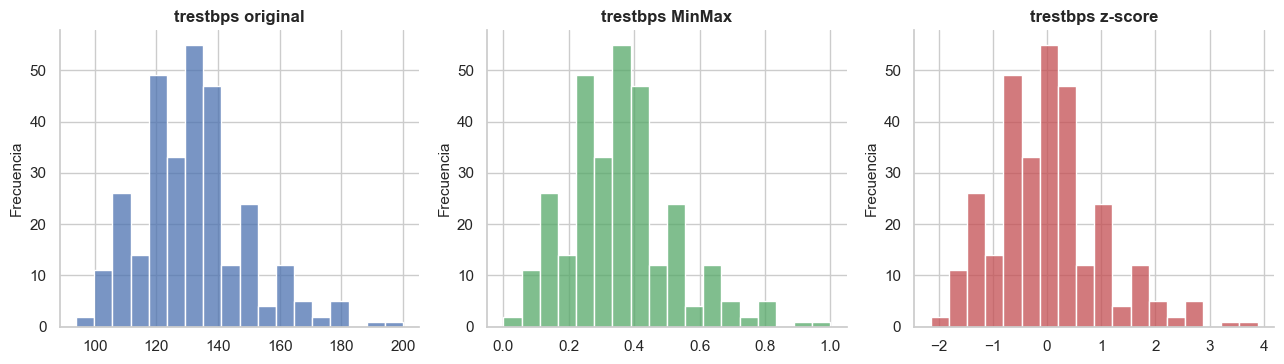

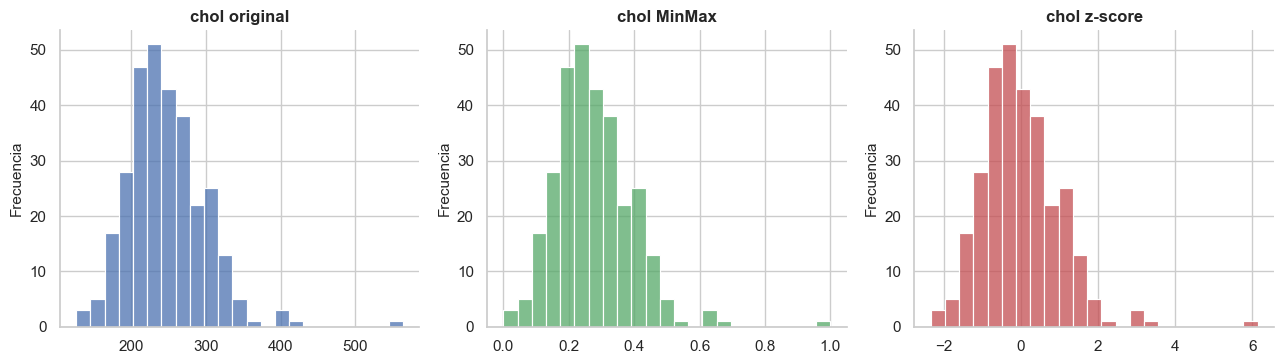

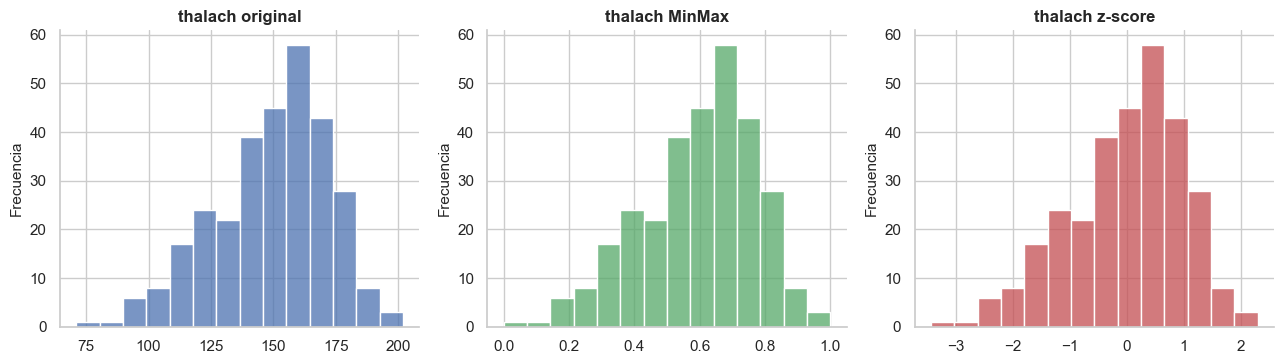

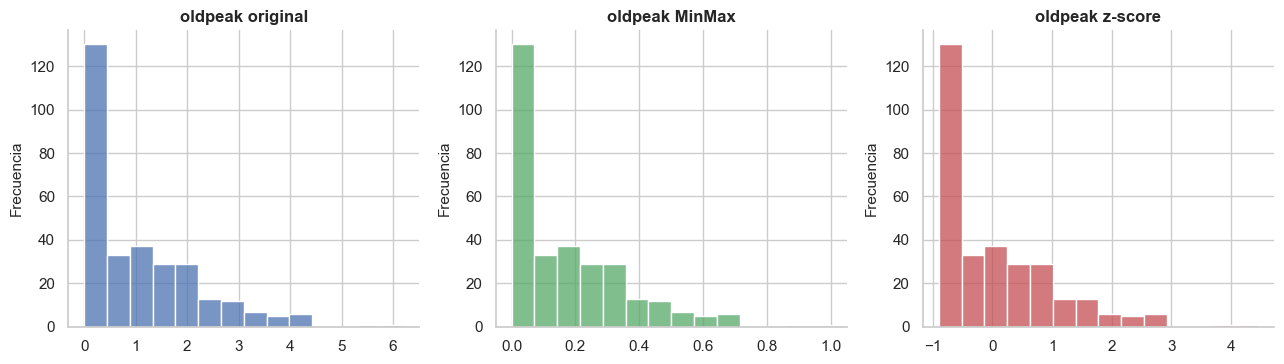

NaN despues del pipeline | train: 0  test: 0


,full_mean,train_mean,test_mean,full_sd,train_sd,test_sd
age,54.439,54.550,54.000,9.039,8.997,9.265
trestbps,131.690,130.959,134.590,17.600,17.623,17.349
chol,246.693,249.839,234.213,51.777,52.847,45.581
thalach,149.607,149.963,148.197,22.875,22.686,23.748
oldpeak,1.040,0.999,1.200,1.161,1.123,1.299


In [11]:
# Punto 24 - Outliers: IQR, Z-score, Isolation Forest
NUM_FOR_OUTLIERS = ['age','trestbps','chol','thalach','oldpeak']
Xnum_full = df[NUM_FOR_OUTLIERS].dropna()
outlier_rows = []
for var in NUM_FOR_OUTLIERS:
    x = df[var].dropna()
    q1, q3 = x.quantile(.25), x.quantile(.75); iqr = q3-q1
    iqr_mask = (x < q1-1.5*iqr) | (x > q3+1.5*iqr)
    z_mask = np.abs(stats.zscore(x)) > 3
    outlier_rows.append([var, int(iqr_mask.sum()), int(z_mask.sum())])
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_pred = iso.fit_predict(Xnum_full); outlier_iso_count = int((iso_pred==-1).sum())
outlier_summary = pd.DataFrame(outlier_rows, columns=['variable','outliers_IQR','outliers_Zscore'])
print('Isolation Forest detecto', outlier_iso_count, 'observaciones atipicas multivariadas.')
display(outlier_summary)
outlier_summary.to_csv(f'{OUT_DIR}/outliers_resumen.csv', index=False)
print('\nDecision clinica: NO se eliminan automaticamente. Los extremos en chol y trestbps son '
      'biologicamente plausibles (hipercolesterolemia, hipertension); eliminarlos sesgaria la senal.')

# Punto 25 - Imputacion en ca y thal: comparacion simple/KNN/iterativa
MISSING_COLS = ['ca','thal']
simple_num = SimpleImputer(strategy='median').fit_transform(df[MISSING_COLS])
knn_num = KNNImputer(n_neighbors=5).fit_transform(df[MISSING_COLS])
iter_num = IterativeImputer(random_state=RANDOM_STATE, max_iter=20).fit_transform(df[MISSING_COLS])
imputacion_comparacion = pd.DataFrame({
    'columna': MISSING_COLS, 'faltantes': df[MISSING_COLS].isna().sum().values,
    'media_simple_mediana': np.nanmean(simple_num, axis=0),
    'media_knn': np.nanmean(knn_num, axis=0),
    'media_iterativa': np.nanmean(iter_num, axis=0)
})
display(imputacion_comparacion)
print('Decision: SimpleImputer (mediana para numericas, moda para categoricas) por simplicidad y '
      'porque con solo 6 NaN los tres metodos producen medias casi identicas.')

# Puntos 26 + 27 + 28 - Codificacion ALINEADA A LA RUBRICA y pipeline sin leakage
X = df.drop(columns=['num','disease'])
y = df['disease']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# Especificacion exacta segun rubrica punto 26:
#   Label Encoding -> sex, exang        (binarias 0/1; ya numericas: passthrough = label)
#   One-Hot       -> cp, restecg        (nominales sin orden)
#   Ordinal       -> slope              (orden clinico 1<2<3)
# Variables no incluidas en p.26, justificadas aparte:
#   fbs   -> binaria 0/1 -> passthrough (equivalente a label encoding)
#   thal  -> nominal 3/6/7 -> One-Hot   (no es ordinal, no se le aplica label arbitrario)
SCALE_COLS = ['age','trestbps','chol','thalach','oldpeak']
COUNT_COLS = ['ca']
LABEL_BIN_COLS = ['sex','exang']
ONEHOT_COLS = ['cp','restecg']
ORDINAL_COLS = ['slope']
EXTRA_BIN_COLS = ['fbs']
EXTRA_ONEHOT_COLS = ['thal']

preprocessor = ColumnTransformer(transformers=[
    ('num_scaled', Pipeline([('imputer', SimpleImputer(strategy='median')),
                             ('scaler', MinMaxScaler())]), SCALE_COLS),
    ('count_scaled', Pipeline([('imputer', SimpleImputer(strategy='median')),
                               ('scaler', MinMaxScaler())]), COUNT_COLS),
    ('label_bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]),
     LABEL_BIN_COLS),   # Label Encoding rubrica
    ('ordinal', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('encoder', OrdinalEncoder(categories=[[1, 2, 3]]))]),
     ORDINAL_COLS),    # Ordinal rubrica
    ('onehot', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     ONEHOT_COLS),    # One-Hot rubrica
    ('extra_bin', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]),
     EXTRA_BIN_COLS),  # fbs aparte
    ('extra_onehot', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                               ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     EXTRA_ONEHOT_COLS),  # thal aparte
], remainder='drop')

pipeline = Pipeline([('preprocessor', preprocessor)])
X_train_t = pipeline.fit_transform(X_train)     # solo fit con train -> sin leakage
X_test_t = pipeline.transform(X_test)
print('Train transformado:', X_train_t.shape, ' | Test transformado:', X_test_t.shape)

# Comparacion MinMax vs Standard
for var in SCALE_COLS:
    a = df[[var]].dropna()
    mm = MinMaxScaler().fit_transform(a)[:,0]
    ss = StandardScaler().fit_transform(a)[:,0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    sns.histplot(a[var], ax=axes[0], color=PRIMARY, edgecolor='white'); axes[0].set_title(f'{var} original')
    sns.histplot(mm, ax=axes[1], color=SECONDARY, edgecolor='white'); axes[1].set_title(f'{var} MinMax')
    sns.histplot(ss, ax=axes[2], color=ACCENT, edgecolor='white'); axes[2].set_title(f'{var} z-score')
    for ax in axes:
        ax.set_xlabel(''); ax.set_ylabel('Frecuencia')
    fig.tight_layout(); fig.savefig(f'{FIG_DIR}/scalers_{var}.png', dpi=FIG_DPI); plt.show()

# Punto 29 - Verificacion train/test
calidad = pd.DataFrame({
    'full_mean': df[SCALE_COLS].mean(), 'train_mean': X_train[SCALE_COLS].mean(),
    'test_mean': X_test[SCALE_COLS].mean(), 'full_sd': df[SCALE_COLS].std(),
    'train_sd': X_train[SCALE_COLS].std(), 'test_sd': X_test[SCALE_COLS].std()
})
print('NaN despues del pipeline | train:', int(np.isnan(X_train_t).sum()),
      ' test:', int(np.isnan(X_test_t).sum()))
display(calidad.round(3))
calidad.to_csv(f'{OUT_DIR}/verificacion_train_test.csv')

## 11. Diagrama de flujo del pipeline y exportacion de resultados

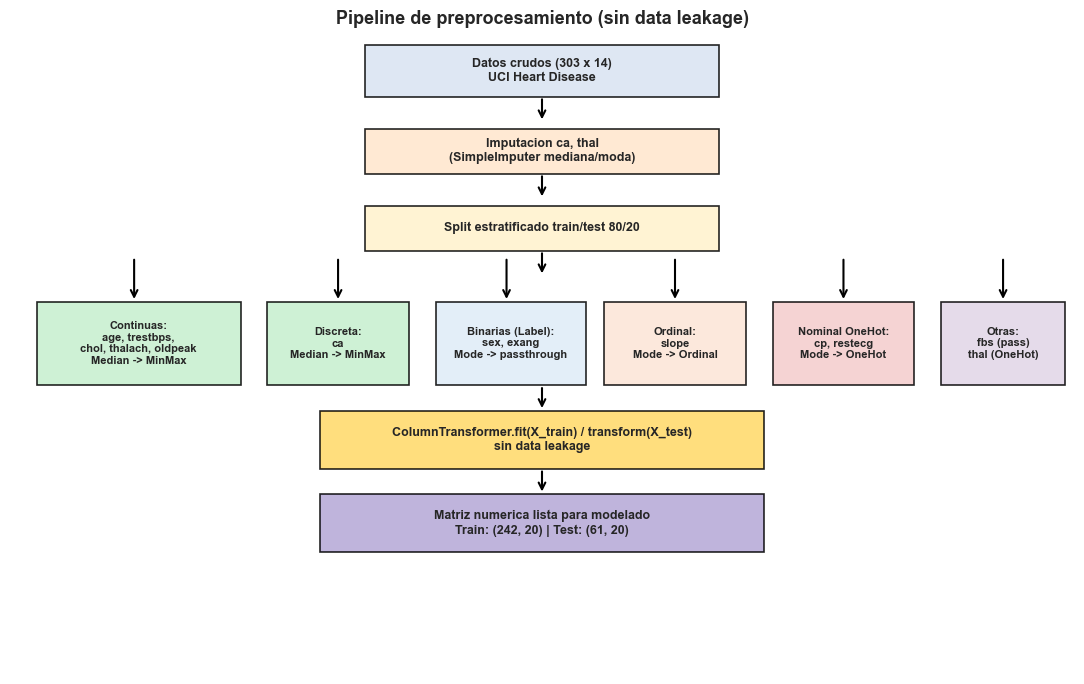

Figuras: 38 | Entregables: 12
Listo - artefactos generados en ./figuras_taller y ./entregables_taller


In [12]:
# Diagrama de flujo del pipeline para el informe
fig, ax = plt.subplots(figsize=(11, 7)); ax.axis('off')
def caja(x,y,w,h,texto,color,fs=9):
    box = plt.Rectangle((x,y),w,h, linewidth=1.2, edgecolor='black', facecolor=color, alpha=0.85)
    ax.add_patch(box); ax.text(x+w/2, y+h/2, texto, ha='center', va='center', fontsize=fs, weight='bold')
def flecha(x1,y1,x2,y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1), arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

ax.set_xlim(0,12); ax.set_ylim(0,10)
caja(4,9,4,0.8,'Datos crudos (303 x 14)\nUCI Heart Disease', '#D9E3F1'); flecha(6,9,6,8.6)
caja(4,7.8,4,0.7, "Imputacion ca, thal\n(SimpleImputer mediana/moda)", '#FFE6CC'); flecha(6,7.8,6,7.4)
caja(4,6.6,4,0.7,'Split estratificado train/test 80/20', '#FFF2CC'); flecha(6,6.6,6,6.2)
caja(0.3,4.5,2.3,1.3,'Continuas:\nage, trestbps,\nchol, thalach, oldpeak\nMedian -> MinMax', '#C6EFCE', 8)
caja(2.9,4.5,1.6,1.3,'Discreta:\nca\nMedian -> MinMax', '#C6EFCE', 8)
caja(4.8,4.5,1.7,1.3,'Binarias (Label):\nsex, exang\nMode -> passthrough', '#DEEBF7', 8)
caja(6.7,4.5,1.6,1.3,'Ordinal:\nslope\nMode -> Ordinal', '#FCE4D6', 8)
caja(8.6,4.5,1.6,1.3,'Nominal OneHot:\ncp, restecg\nMode -> OneHot', '#F4CCCC', 8)
caja(10.5,4.5,1.4,1.3,'Otras:\nfbs (pass)\nthal (OneHot)', '#E1D5E7', 8)
for x in [1.4,3.7,5.6,7.5,9.4,11.2]:
    flecha(x, 6.5, x, 5.8)
flecha(6,4.5,6,4.1)
caja(3.5,3.2,5,0.9, 'ColumnTransformer.fit(X_train) / transform(X_test)\nsin data leakage', '#FFD966')
flecha(6,3.2,6,2.8)
caja(3.5,1.9,5,0.9, f'Matriz numerica lista para modelado\nTrain: {X_train_t.shape} | Test: {X_test_t.shape}', '#B4A7D6')
ax.set_title('Pipeline de preprocesamiento (sin data leakage)', fontsize=13, weight='bold')
fig.tight_layout(); fig.savefig(f'{FIG_DIR}/pipeline_diagrama.png', dpi=FIG_DPI, bbox_inches='tight'); plt.show()

# Exportar todos los resultados en un Excel consolidado
with pd.ExcelWriter(f'{OUT_DIR}/resultados_taller_heart_disease.xlsx') as writer:
    diccionario.to_excel(writer, sheet_name='diccionario', index=False)
    clasificacion.to_excel(writer, sheet_name='clasificacion', index=False)
    diagnostico.to_excel(writer, sheet_name='diagnostico')
    desc.round(4).to_excel(writer, sheet_name='descriptivos')
    formas.to_excel(writer, sheet_name='formas', index=False)
    top_p.to_excel(writer, sheet_name='top_pearson', index=False)
    top_s.to_excel(writer, sheet_name='top_spearman', index=False)
    mle_normal.round(4).to_excel(writer, sheet_name='normalidad', index=False)
    ajuste_no_normal.to_excel(writer, sheet_name='oldpeak_ajuste', index=False)
    inferencia.round(5).to_excel(writer, sheet_name='inferencia', index=False)
    tukey_df.to_excel(writer, sheet_name='tukey_thalach_cp', index=False)
    outlier_summary.to_excel(writer, sheet_name='outliers', index=False)
    imputacion_comparacion.to_excel(writer, sheet_name='imputacion', index=False)
    calidad.round(4).to_excel(writer, sheet_name='train_test')

print('Figuras:', len(os.listdir(FIG_DIR)), '| Entregables:', len(os.listdir(OUT_DIR)))
print('Listo - artefactos generados en', FIG_DIR, 'y', OUT_DIR)

## 12. Conclusion guia para el informe tecnico

Hallazgos centrales para el informe (ver `Informe_Tecnico_Heart_Disease.docx` para la redaccion completa):

1. **Variables predictoras mas fuertes:** `ca` (vasos coloreados), `oldpeak` (depresion ST), `thalach`
   (FC maxima) y el patron clinico `cp` (asintomatico vs angina tipica) concentran la senal frente a
   `disease`. El colesterol aislado **no** muestra diferencia significativa entre sanos y enfermos en
   este dataset (Welch p_one=0.068, IC95% de la diferencia cruza el cero).

2. **Distribuciones:** ninguna de las tres continuas evaluadas (`age`, `thalach`, `chol`) cumple
   normalidad estricta; `oldpeak` se ajusta significativamente mejor a una **gamma** que a una
   exponencial sobre sus valores positivos (AIC 557.7 vs 587.3).

3. **Asociacion sexo-enfermedad:** chi-cuadrada significativa (p=2.7e-6) con V de Cramer = 0.270; los
   hombres tienen tasa de enfermedad del 55.3% frente a 25.8% en mujeres. La proporcion global de
   enfermedad es 45.9% con IC95% Wilson [0.404, 0.515].

4. **Pipeline reproducible:** ColumnTransformer con imputacion en `ca` y `thal`, escalado MinMax para
   continuas, codificacion alineada a la rubrica, ajustado solo con train. La diferencia train vs test
   en medias/DE es pequena (p.ej. `chol`: train 249.8 vs test 234.2), aceptable con n=303.

Todos los CSV y figuras estan en `./entregables_taller` y `./figuras_taller`.